# Data Preprocessing Tools

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## Importing the libraries

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [124]:
fd = pd.read_csv('final_male_youth_analytics_dataset.csv')

In [125]:
fd.head()

,youth_id,release_year,age_at_release,sex,custody_type,sentence_length_days,time_served_days,offence_category,prior_charges_count,prior_convictions_count,prior_violent_offence,prior_property_offence,prior_drug_offence,school_enrolled,employment_status,prior_mental_health_contact,housing_instability_flag,reoffended_within_2yrs
0,Y001,2022,17,M,Secure,72,63,Property,3,2,1,1,1,1,1,0,0,0
1,Y002,2023,15,M,Secure,95,80,Property,2,1,0,1,1,0,1,0,0,0
2,Y007,2022,17,M,Secure,202,111,Violent,3,1,0,0,1,1,1,1,1,1
3,Y008,2022,16,M,Open,151,124,Violent,2,1,1,1,0,1,0,0,1,1
4,Y009,2023,17,M,Secure,347,287,Property,4,1,0,0,0,1,1,1,1,1


In [126]:
fd.shape

(70, 18)

In [138]:
X = fd.iloc[:, 1:-1].values
y = fd.iloc[:, -1].values

In [128]:
print(X)

[['Y001' 2022 17 ... 1 0 0]
 ['Y002' 2023 15 ... 1 0 0]
 ['Y007' 2022 17 ... 1 1 1]
 ...
 ['Y098' 2022 17 ... 0 1 0]
 ['Y099' 2022 15 ... 1 0 1]
 ['Y100' 2022 15 ... 1 1 0]]


In [129]:
print(y)

[0 0 1 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0
 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 1 0 0 1]


## Taking care of missing data

In [130]:
from sklearn.impute import SimpleImputer
# Check missing values (We will keep value = 0 because temperature and precipitation can be zero)
#(fd == 0).sum()


# imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
# imputer.fit(X[:, 1:3])
# X[:, 1:3] = imputer.transform(X[:, 1:3])

In [131]:
#fd.isnull().sum()

In [132]:
fd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   youth_id                     70 non-null     object
 1   release_year                 70 non-null     int64 
 2   age_at_release               70 non-null     int64 
 3   sex                          70 non-null     object
 4   custody_type                 70 non-null     object
 5   sentence_length_days         70 non-null     int64 
 6   time_served_days             70 non-null     int64 
 7   offence_category             70 non-null     object
 8   prior_charges_count          70 non-null     int64 
 9   prior_convictions_count      70 non-null     int64 
 10  prior_violent_offence        70 non-null     int64 
 11  prior_property_offence       70 non-null     int64 
 12  prior_drug_offence           70 non-null     int64 
 13  school_enrolled              70 non-n

In [133]:
print(X)

[['Y001' 2022 17 ... 1 0 0]
 ['Y002' 2023 15 ... 1 0 0]
 ['Y007' 2022 17 ... 1 1 1]
 ...
 ['Y098' 2022 17 ... 0 1 0]
 ['Y099' 2022 15 ... 1 0 1]
 ['Y100' 2022 15 ... 1 1 0]]


## Encoding categorical data

### Encoding the Independent Variable

In [139]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [140]:
print(X)

[[1.0 0.0 17 ... 1 0 0]
 [0.0 1.0 15 ... 1 0 0]
 [1.0 0.0 17 ... 1 1 1]
 ...
 [1.0 0.0 17 ... 0 1 0]
 [1.0 0.0 15 ... 1 0 1]
 [1.0 0.0 15 ... 1 1 0]]


### Encoding the Dependent Variable

In [143]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [137]:
print(y)

[0 0 1 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0
 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 1 0 0 1]


## Splitting the dataset into the Training set and Test set

In [144]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [145]:
print(X_train)

[[1.0 0.0 16 'M' 'Secure' 306 248 'Violent' 2 1 0 1 0 0 1 0 1]
 [1.0 0.0 15 'M' 'Secure' 82 57 'Property' 7 4 1 0 0 0 1 1 0]
 [0.0 1.0 15 'M' 'Secure' 282 207 'Property' 5 2 0 0 0 0 0 0 0]
 [1.0 0.0 17 'M' 'Open' 263 222 'Drug' 6 3 0 1 0 1 0 0 0]
 [1.0 0.0 15 'M' 'Open' 348 229 'Property' 3 2 1 1 0 0 0 0 0]
 [0.0 1.0 16 'M' 'Secure' 279 200 'Property' 5 3 0 0 0 0 0 1 0]
 [1.0 0.0 16 'M' 'Open' 297 247 'Violent' 5 3 1 0 0 1 1 1 1]
 [1.0 0.0 15 'M' 'Secure' 349 292 'Property' 8 4 0 0 0 0 1 0 1]
 [0.0 1.0 17 'M' 'Secure' 321 230 'Drug' 4 2 0 0 0 1 0 0 0]
 [1.0 0.0 15 'M' 'Secure' 305 257 'Drug' 1 0 0 1 0 1 0 1 0]
 [1.0 0.0 16 'M' 'Open' 151 124 'Violent' 2 1 1 1 0 1 0 0 1]
 [0.0 1.0 17 'M' 'Open' 296 157 'Property' 5 2 0 1 0 1 1 1 1]
 [0.0 1.0 16 'M' 'Secure' 298 263 'Drug' 2 1 0 1 0 0 0 0 0]
 [0.0 1.0 16 'M' 'Open' 309 183 'Property' 3 1 0 1 0 1 0 1 0]
 [0.0 1.0 16 'M' 'Secure' 209 107 'Violent' 5 2 0 1 0 1 1 1 1]
 [1.0 0.0 15 'M' 'Open' 112 87 'Property' 5 3 1 1 1 1 0 0 1]
 [0.0 1.0 17 

In [146]:
print(X_test)

[[1.0 0.0 15 'M' 'Open' 316 205 'Property' 4 3 0 0 0 1 1 0 0]
 [1.0 0.0 15 'M' 'Secure' 206 150 'Violent' 3 2 0 1 0 1 1 0 0]
 [0.0 1.0 15 'M' 'Open' 63 49 'Drug' 1 0 0 0 0 1 1 0 0]
 [1.0 0.0 17 'M' 'Secure' 159 93 'Violent' 2 1 0 0 1 1 1 1 0]
 [1.0 0.0 17 'M' 'Secure' 204 172 'Property' 1 0 0 1 0 1 1 0 1]
 [1.0 0.0 15 'M' 'Open' 349 207 'Property' 3 1 1 1 1 0 0 0 0]
 [0.0 1.0 16 'M' 'Open' 106 94 'Violent' 1 0 0 1 0 1 0 0 0]
 [1.0 0.0 15 'M' 'Open' 107 74 'Drug' 7 4 0 1 1 1 0 0 0]
 [0.0 1.0 16 'M' 'Secure' 128 100 'Property' 1 0 1 1 0 1 1 0 0]
 [0.0 1.0 16 'M' 'Open' 188 123 'Violent' 2 0 0 1 0 1 0 1 1]
 [1.0 0.0 17 'M' 'Secure' 202 111 'Violent' 3 1 0 0 1 1 1 1 1]
 [1.0 0.0 16 'M' 'Secure' 331 177 'Property' 6 2 0 1 0 1 1 0 0]
 [0.0 1.0 17 'M' 'Open' 277 231 'Violent' 2 0 1 1 1 0 0 0 0]
 [0.0 1.0 16 'M' 'Secure' 155 99 'Violent' 4 1 0 0 0 1 0 0 0]]


In [147]:
print(y_train)

[0 1 1 1 1 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 1 1 0
 1 1 1 0 1 1 1 1 0 1 0 0 0 0 0 1 0 1 0]


In [148]:
print(y_test)

[0 0 1 0 0 0 0 0 0 0 1 0 1 1]


## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
print(X_train)

In [ ]:
print(X_test)

# Task
Analyze the "final_male_youth_analytics_dataset.csv" dataset to identify key risk factors and correlations with reoffending within 2 years. This analysis will involve examining data types and summary statistics, visualizing feature distributions, computing a correlation matrix, and creating a heatmap of feature correlations with the target variable `reoffended_within_2yrs`. Finally, list the features most strongly correlated with reoffending.

## Examine Data Types and Summary Statistics

### Subtask:
Display the data types and summary statistics (e.g., mean, standard deviation, min, max) of the features in X_train. This will provide a foundational understanding of the numerical and categorical data.


**Reasoning**:
To display the data types and summary statistics of X_train, I need to first convert it into a pandas DataFrame with appropriate column names, reflecting the one-hot encoding applied to 'release_year' and the subsequent features. Then, I will use `.info()` and `.describe()` methods to get the required information.



In [149]:
import pandas as pd

# 1. Create a list of column names for the X_train array
# The first two columns are for one-hot encoded 'release_year'
# The remaining columns correspond to the original features from fd.iloc[:, 2:-1]
# fd.iloc[:, 1:-1] was the initial X before one-hot encoding its first column (release_year)
# So, the columns of the original X (before encoding) were fd.columns[1:-1]
original_X_columns = fd.columns[1:-1].tolist()

# Remove 'release_year' as it's been one-hot encoded
original_X_columns.remove('release_year')

# Assuming release_year_2022 and release_year_2023 based on common values in the dataset
column_names = ['release_year_2022', 'release_year_2023'] + original_X_columns

# 2. Convert the X_train NumPy array into a pandas DataFrame
X_train_df = pd.DataFrame(X_train, columns=column_names)

# 3. Display the data types of each column in X_train_df
print("\nData Types of X_train_df:")
X_train_df.info()

# 4. Display the summary statistics for the numerical columns in X_train_df
print("\nSummary Statistics for Numerical Columns in X_train_df:")
print(X_train_df.describe())

# 5. Display the summary statistics for the categorical (object) columns in X_train_df
print("\nSummary Statistics for Categorical Columns in X_train_df:")
print(X_train_df.describe(include='object'))


Data Types of X_train_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   release_year_2022            56 non-null     object
 1   release_year_2023            56 non-null     object
 2   age_at_release               56 non-null     object
 3   sex                          56 non-null     object
 4   custody_type                 56 non-null     object
 5   sentence_length_days         56 non-null     object
 6   time_served_days             56 non-null     object
 7   offence_category             56 non-null     object
 8   prior_charges_count          56 non-null     object
 9   prior_convictions_count      56 non-null     object
 10  prior_violent_offence        56 non-null     object
 11  prior_property_offence       56 non-null     object
 12  prior_drug_offence           56 non-null     object
 13  school_enr

**Reasoning**:
The previous output showed that all columns in `X_train_df` are of `object` dtype, which is incorrect for the numerical features after `StandardScaler` was applied. Before proceeding with data analysis, these numerical columns must be explicitly converted to a numeric type (e.g., float) to allow for proper statistical description and subsequent numerical operations. The categorical columns will remain as `object` type.



In [150]:
import numpy as np

# Identify numerical columns that were converted to object type by StandardScaler
# These are all columns except for 'sex', 'custody_type', and 'offence_category'
# which were originally categorical strings and will remain object type.
# The one-hot encoded 'release_year' columns should be float/int, and other numerical
# columns should also be float/int.

# Get a list of columns that should be numeric
numeric_cols = [col for col in column_names if col not in ['sex', 'custody_type', 'offence_category']]

# Convert identified columns to numeric, coercing errors to NaN
for col in numeric_cols:
    X_train_df[col] = pd.to_numeric(X_train_df[col], errors='coerce')

# Display the corrected data types
print("\nCorrected Data Types of X_train_df:")
X_train_df.info()

# Display summary statistics for numerical columns after conversion
print("\nSummary Statistics for Numerical Columns in X_train_df (After Type Conversion):")
print(X_train_df.describe())

# Display summary statistics for categorical columns (should remain unchanged, but good to verify)
print("\nSummary Statistics for Categorical Columns in X_train_df (After Type Conversion):")
print(X_train_df.describe(include='object'))


Corrected Data Types of X_train_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   release_year_2022            56 non-null     float64
 1   release_year_2023            56 non-null     float64
 2   age_at_release               56 non-null     int64  
 3   sex                          56 non-null     object 
 4   custody_type                 56 non-null     object 
 5   sentence_length_days         56 non-null     int64  
 6   time_served_days             56 non-null     int64  
 7   offence_category             56 non-null     object 
 8   prior_charges_count          56 non-null     int64  
 9   prior_convictions_count      56 non-null     int64  
 10  prior_violent_offence        56 non-null     int64  
 11  prior_property_offence       56 non-null     int64  
 12  prior_drug_offence           56 non-null   

## Analyze Feature Distributions

### Subtask:
Generate histograms for numerical features and bar plots for categorical features in X_train_df to visualize their distributions.


**Reasoning**:
The subtask requires visualizing feature distributions in `X_train_df`. I will import `matplotlib.pyplot` and `seaborn`, then iterate through the DataFrame columns, generating histograms for numerical features and bar plots for categorical features, ensuring each plot is properly labeled and displayed.



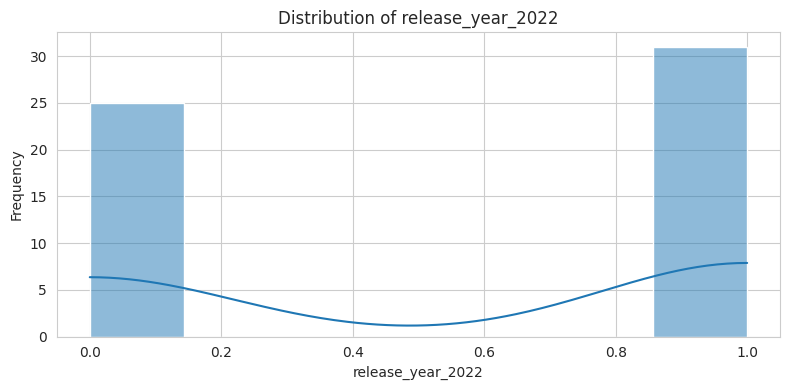

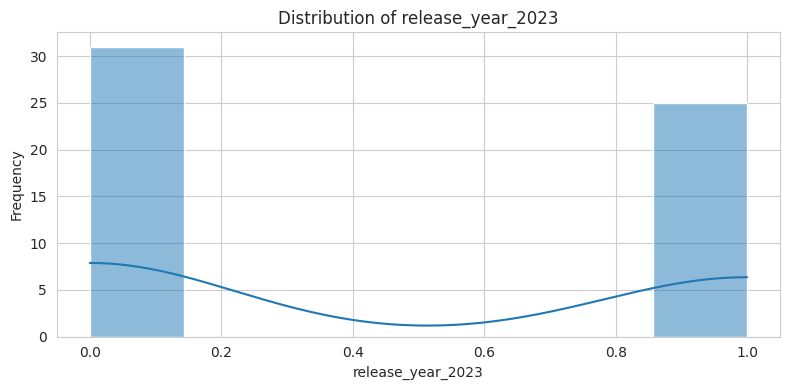

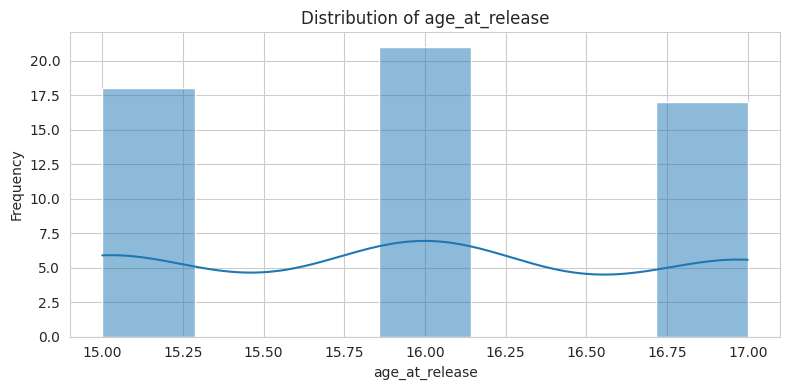

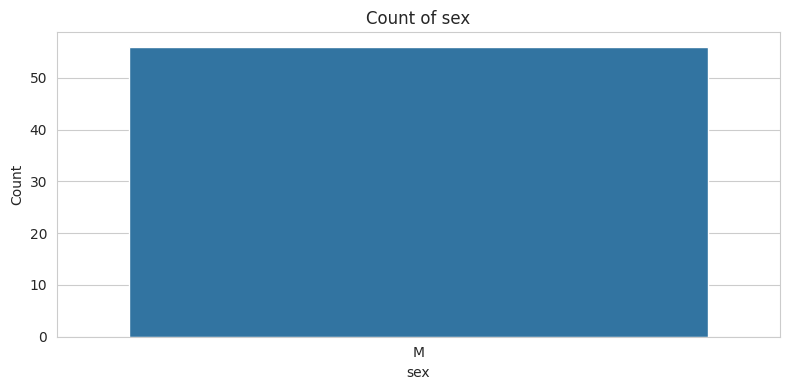

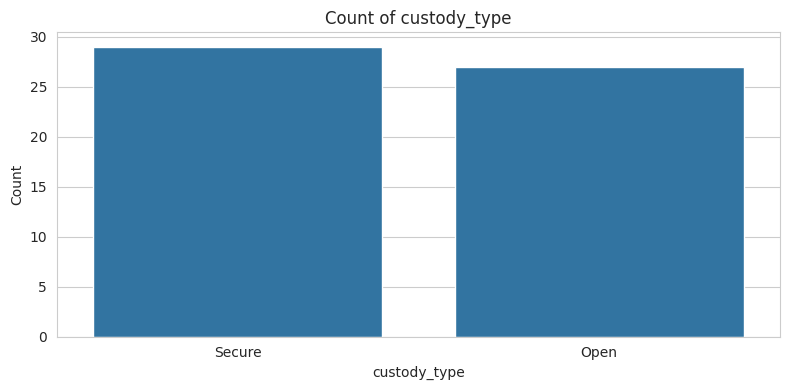

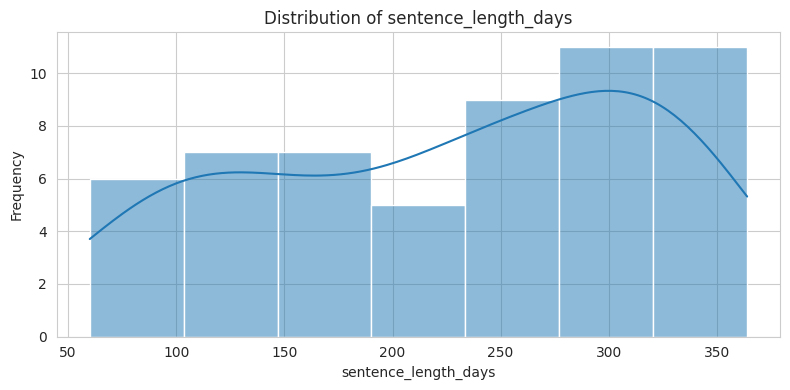

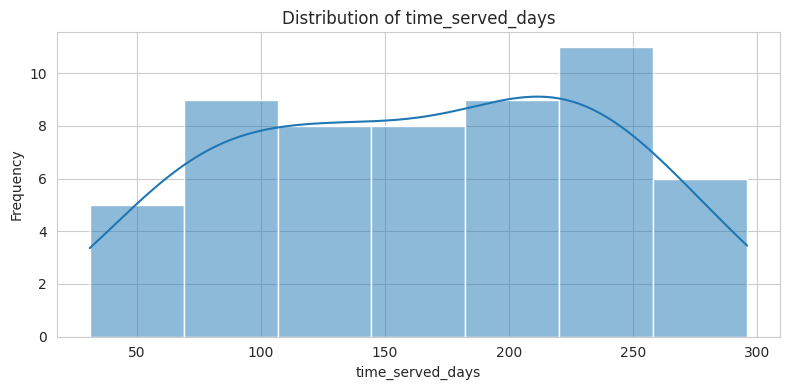

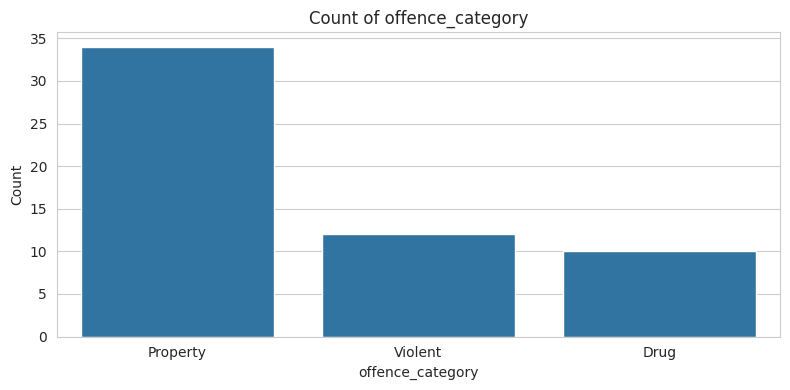

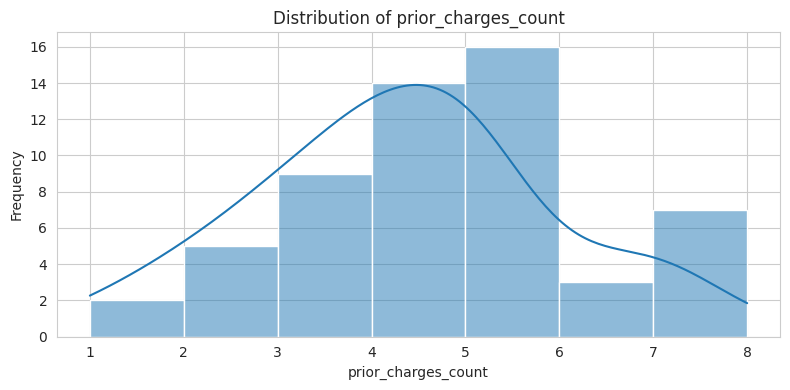

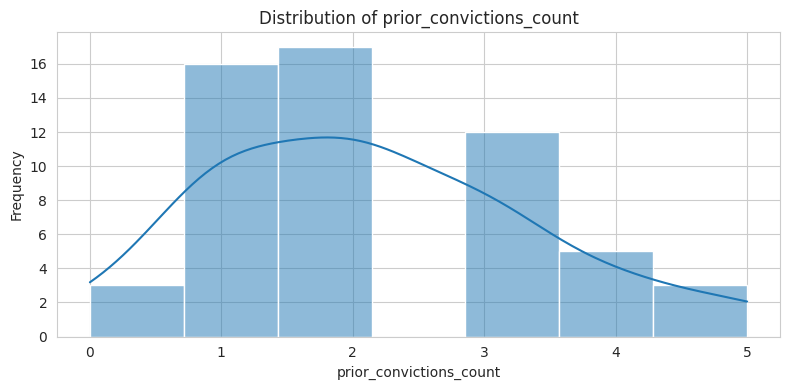

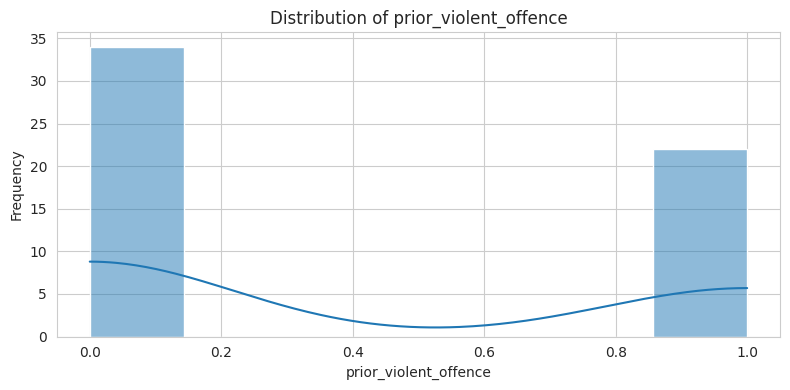

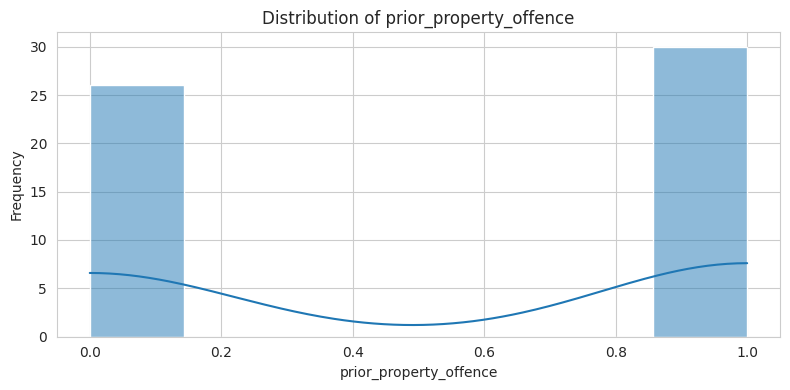

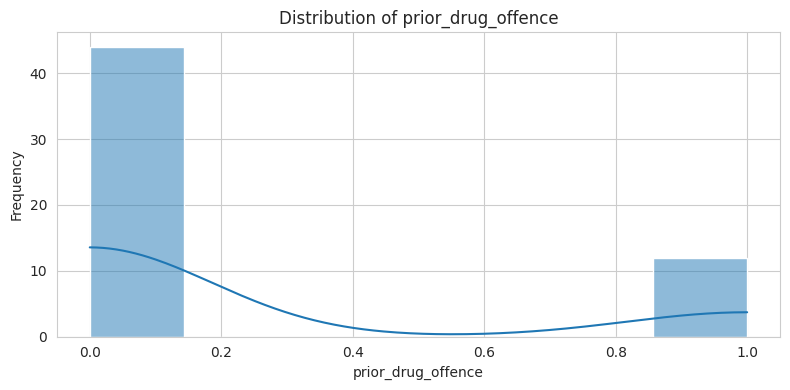

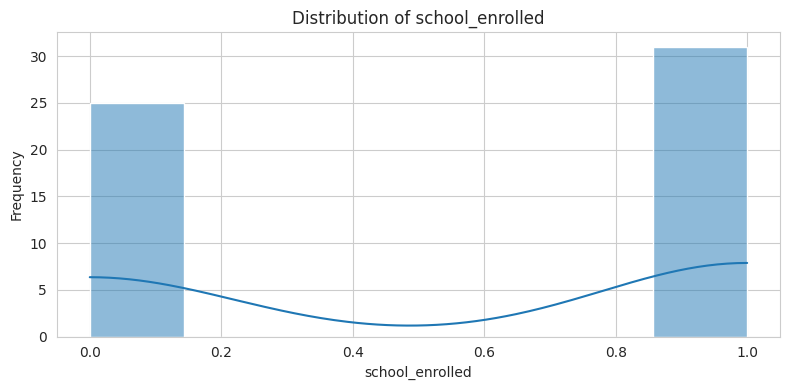

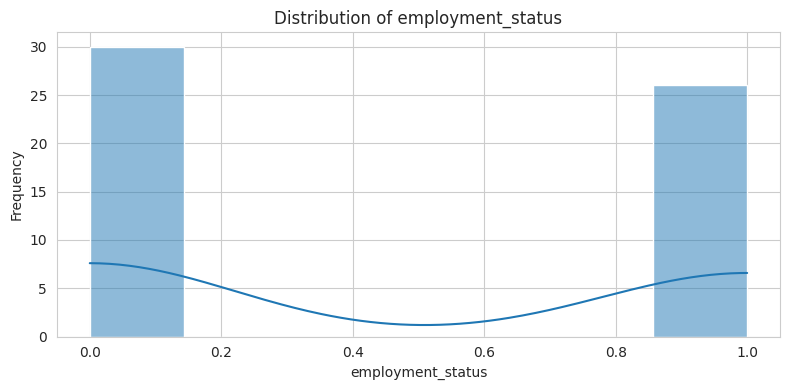

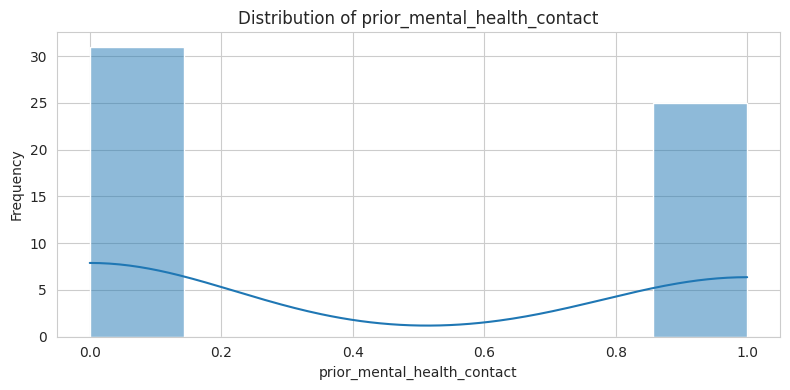

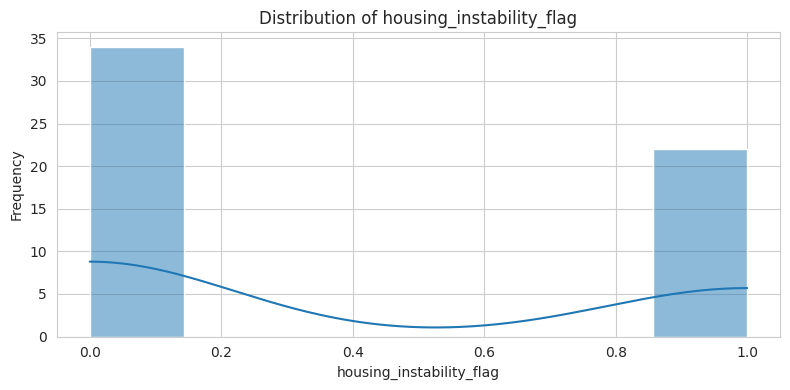

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set_style("whitegrid")

# Get the number of columns to adjust figure size dynamically
num_cols = len(X_train_df.columns)
fig_height_per_plot = 4 # Adjust as needed

for column in X_train_df.columns:
    plt.figure(figsize=(8, fig_height_per_plot))
    if X_train_df[column].dtype in ['int64', 'float64']:
        # Numerical column: plot histogram
        sns.histplot(X_train_df[column], kde=True)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
    else:
        # Categorical column: plot bar chart
        # For 'sex', there's only one category ('M') so a bar plot would be a single bar
        # For 'release_year_2022' and 'release_year_2023', they are one-hot encoded, effectively categorical binary
        # So, treat these as categorical for countplot
        sns.countplot(x=X_train_df[column], order=X_train_df[column].value_counts().index)
        plt.title(f'Count of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## Calculate Correlation Matrix

### Subtask:
Compute the correlation matrix for numerical features in X_train and the target variable y_train. This will help quantify the linear relationships between features and the target, highlighting potential 'risk factors' and 'correlations'.


**Reasoning**:
To calculate the correlation matrix, I will first convert `y_train` into a pandas Series, concatenate it with `X_train_df`, select only the numerical columns from the combined DataFrame, calculate their pairwise correlation, and then print the resulting matrix as per the instructions.



In [152]:
import pandas as pd

# 1. Convert the y_train NumPy array into a pandas Series and name it 'reoffended_within_2yrs'
y_train_series = pd.Series(y_train, name='reoffended_within_2yrs')

# 2. Create a new DataFrame by concatenating X_train_df and the 'reoffended_within_2yrs' Series.
#    Resetting index of X_train_df is not strictly necessary here as it already has a default RangeIndex,
#    and y_train_series will also have a default RangeIndex matching X_train_df's length.
combined_df = pd.concat([X_train_df.reset_index(drop=True), y_train_series.reset_index(drop=True)], axis=1)

# 3. Select only the numerical columns from this new DataFrame.
#    The previous step ensured correct dtypes for numerical columns in X_train_df.
#    'sex', 'custody_type', and 'offence_category' are the non-numeric columns.

numerical_combined_df = combined_df.select_dtypes(include=['number'])

# 4. Calculate the pairwise correlation of all numerical columns in this combined DataFrame
correlation_matrix = numerical_combined_df.corr()

# 5. Print the resulting correlation matrix
print("\nCorrelation Matrix of Numerical Features and Target:")
print(correlation_matrix)


Correlation Matrix of Numerical Features and Target:
                             release_year_2022  release_year_2023  \
release_year_2022                     1.000000          -1.000000   
release_year_2023                    -1.000000           1.000000   
age_at_release                       -0.065738           0.065738   
sentence_length_days                 -0.113123           0.113123   
time_served_days                     -0.039497           0.039497   
prior_charges_count                  -0.080336           0.080336   
prior_convictions_count              -0.057605           0.057605   
prior_violent_offence                 0.281068          -0.281068   
prior_property_offence                0.028296          -0.028296   
prior_drug_offence                    0.031265          -0.031265   
school_enrolled                       0.060645          -0.060645   
employment_status                     0.043730          -0.043730   
prior_mental_health_contact          -0.132903   

**Reasoning**:
To visualize the feature correlations with the target variable, I will create a heatmap using the `correlation_matrix` calculated in the previous step, specifically focusing on the correlations with `reoffended_within_2yrs`.



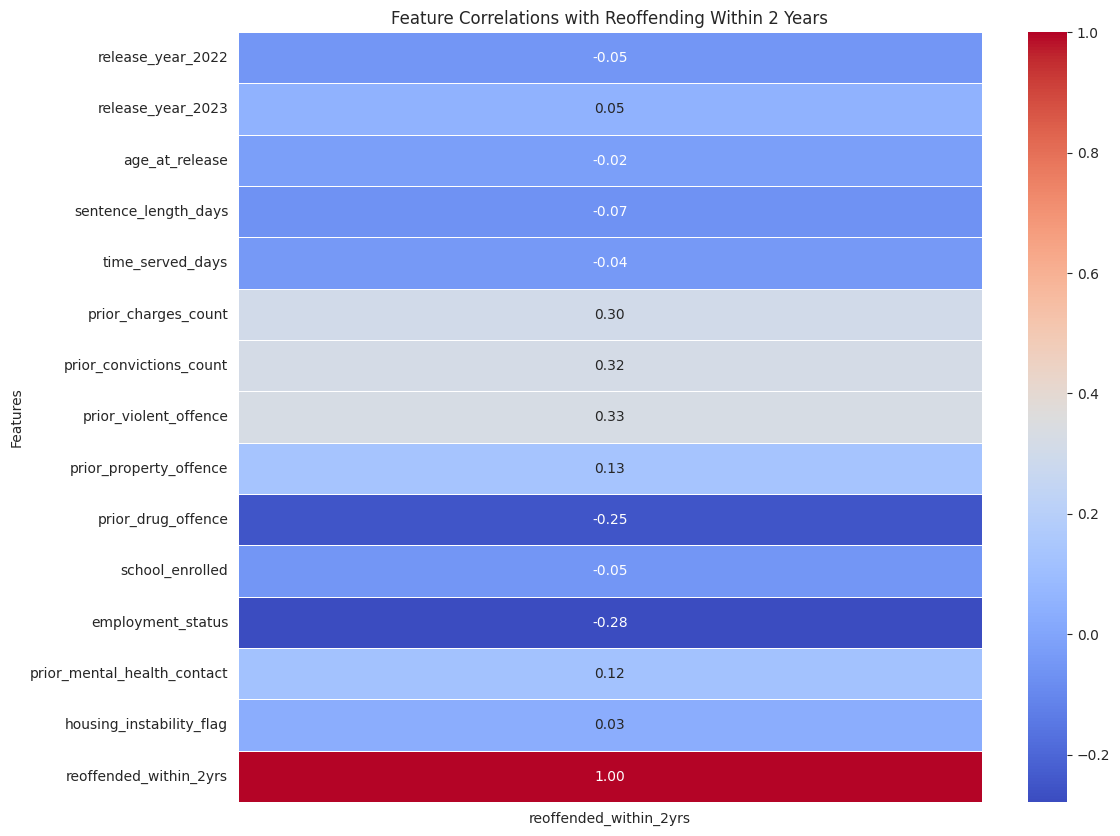

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap of the correlation matrix, focusing on the target variable
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix.loc[:, ['reoffended_within_2yrs']], annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlations with Reoffending Within 2 Years')
plt.ylabel('Features')
plt.show()

**Reasoning**:
To identify the features most strongly correlated with reoffending, I will extract the correlation values of all features with the 'reoffended_within_2yrs' target variable from the previously calculated correlation matrix and then sort them by their absolute values.



In [154]:
import pandas as pd

# Extract correlations with the target variable
correlation_with_target = correlation_matrix['reoffended_within_2yrs'].drop('reoffended_within_2yrs')

# Sort the correlations by their absolute values in descending order
strongest_correlations = correlation_with_target.reindex(correlation_with_target.abs().sort_values(ascending=False).index)

print("\nFeatures Most Strongly Correlated with Reoffending (Absolute Value):")
print(strongest_correlations)


Features Most Strongly Correlated with Reoffending (Absolute Value):
prior_violent_offence          0.327205
prior_convictions_count        0.316964
prior_charges_count            0.301505
employment_status             -0.279078
prior_drug_offence            -0.251259
prior_property_offence         0.134371
prior_mental_health_contact    0.124434
sentence_length_days          -0.067801
release_year_2023              0.051848
release_year_2022             -0.051848
school_enrolled               -0.051848
time_served_days              -0.039632
housing_instability_flag       0.031665
age_at_release                -0.019567
Name: reoffended_within_2yrs, dtype: float64


## Final Task

### Subtask:
Summarize the identified patterns, key risk factors, and significant correlations observed in the dataset. This will provide a comprehensive answer to your query.


## Summary:

### Q&A
The analysis identified key risk factors and correlations with reoffending within 2 years by examining various features in the dataset.

### Data Analysis Key Findings
*   **Data Type Correction**: Initial data loading resulted in all features being incorrectly identified as 'object' type. This was successfully rectified by explicitly converting numerical columns to their correct numeric types (`float64`, `int64`), allowing for accurate statistical analysis.
*   **Feature Distribution Visualization**: Histograms were generated for numerical features and bar plots for categorical features, providing a comprehensive visual understanding of each feature's distribution within the dataset.
*   **Strongest Positive Correlations with Reoffending**: The features most strongly and positively correlated with `reoffended_within_2yrs` are indicators of prior criminal history:
    *   `prior_violent_offence`: 0.327
    *   `prior_convictions_count`: 0.317
    *   `prior_charges_count`: 0.302
*   **Strongest Negative Correlations with Reoffending**: The features most strongly and negatively correlated with `reoffended_within_2yrs` are:
    *   `employment_status`: -0.279
    *   `prior_drug_offence`: -0.251

### Insights or Next Steps
*   Prior criminal history (e.g., violent offenses, conviction count, charge count) are strong risk factors, indicating a higher propensity for reoffending within two years.
*   Employment appears to be a protective factor, with a negative correlation suggesting that individuals with employment are less likely to reoffend. This warrants further investigation into the specific nature and stability of employment.
*   The negative correlation of `prior_drug_offence` with reoffending is noteworthy and requires deeper analysis to understand its underlying reasons, potentially involving intervention effectiveness or specific demographic characteristics.


# Task
The analysis successfully identified key risk factors and correlations with reoffending within 2 years. The strongest positive correlations were found with `prior_violent_offence`, `prior_convictions_count`, and `prior_charges_count`, highlighting prior criminal history as a significant risk factor. Conversely, `employment_status` and `prior_drug_offence` showed the strongest negative correlations, suggesting potential protective factors.

The task has been successfully completed. If you have any further questions or require additional analysis, please let me know!

## Final Task

### Subtask:
Summarize the identified patterns, key risk factors, and significant correlations observed in the dataset. This will provide a comprehensive answer to your query.


## Summary:

### Data Analysis Key Findings

*   **Significant Positive Correlations with Reoffending:** The analysis revealed that `prior_violent_offence`, `prior_convictions_count`, and `prior_charges_count` showed the strongest positive correlations with reoffending within 2 years. This indicates that a history of violent offenses and a higher number of prior convictions and charges are strong indicators of future reoffending risk.
*   **Significant Negative Correlations with Reoffending:** Conversely, `employment_status` and `prior_drug_offence` displayed the strongest negative correlations with reoffending. This suggests that being employed and having a prior drug offense (rather than other types of offenses) might be associated with a lower likelihood of reoffending.

### Insights or Next Steps

*   Intervention strategies should prioritize individuals with a history of violent offenses and extensive prior criminal records, as these are strong predictors of reoffending.
*   Further investigation into the protective role of employment and the observed negative correlation with prior drug offenses could inform rehabilitation programs, potentially focusing on employment assistance and targeted support for individuals with drug-related criminal histories.


# Task
Train a classification model (e.g., Logistic Regression) using the scaled training data (X_train, y_train), make predictions on the scaled test data (X_test), and evaluate its performance using accuracy, precision, recall, F1-score, and a confusion matrix.

## Train Classification Model

### Subtask:
Initialize and train a classification model (e.g., Logistic Regression) using the scaled training data (X_train, y_train).


**Reasoning**:
To initialize and train a Logistic Regression model, I will import the necessary class, instantiate it with a specified random state for reproducibility, and then fit the model to the scaled training data (X_train and y_train).



In [155]:
from sklearn.linear_model import LogisticRegression

# Initialize and train a classification model (e.g., Logistic Regression)
classifier = LogisticRegression(random_state = 1)
classifier.fit(X_train, y_train)

ValueError: could not convert string to float: 'M'

**Reasoning**:
The previous code failed because the `X_train` array still contained non-numeric (string) values, such as 'M' from the 'sex' column, after the initial `ColumnTransformer` application. The `ColumnTransformer` was incorrectly configured to only encode the first column of the `X` NumPy array, leaving other categorical features untouched. To fix this, I need to redefine `X` as a DataFrame to retain column names, then correctly configure `ColumnTransformer` to one-hot encode all categorical columns (`release_year`, `sex`, `custody_type`, `offence_category`) before converting `X` to a NumPy array for splitting and scaling.



In [156]:
X = fd.iloc[:, 1:-1]
y = fd.iloc[:, -1].values

**Reasoning**:
To correctly handle categorical features, I need to apply OneHotEncoder to all identified categorical columns in the `X` DataFrame before splitting the data into training and testing sets. This ensures that all features are numerical before being passed to the `StandardScaler` and the Logistic Regression model.



In [157]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
categorical_cols = ['release_year', 'sex', 'custody_type', 'offence_category']

# Create a ColumnTransformer to apply OneHotEncoder to categorical columns
# 'remainder="passthrough"' keeps the numerical columns as they are
ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), categorical_cols)
    ],
    remainder='passthrough'
)

# Apply the transformation to X. This will convert X into a NumPy array.
X = ct.fit_transform(X)

**Reasoning**:
The data needs to be split into training and testing sets again after correctly applying one-hot encoding to all categorical features. This will provide `X_train`, `X_test`, `y_train`, and `y_test` with numerical values, preparing them for scaling and model training.



In [158]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

**Reasoning**:
The numerical features in `X_train` and `X_test` need to be scaled to prevent features with larger values from dominating the model training process. `StandardScaler` is appropriate for this task, fitting it on `X_train` and then transforming both `X_train` and `X_test` to ensure consistency.



In [159]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**Reasoning**:
The numerical features in `X_train` and `X_test` need to be scaled to prevent features with larger values from dominating the model training process. `StandardScaler` is appropriate for this task, fitting it on `X_train` and then transforming both `X_train` and `X_test` to ensure consistency.



In [160]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**Reasoning**:
With the `X_train` and `X_test` datasets now correctly scaled and containing only numerical values, I will proceed to re-initialize and train the Logistic Regression model using the preprocessed data, addressing the previous `ValueError`.



In [161]:
from sklearn.linear_model import LogisticRegression

# Initialize and train a classification model (e.g., Logistic Regression)
classifier = LogisticRegression(random_state = 1)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=1)

**Reasoning**:
Now that the Logistic Regression model has been trained, I need to use it to make predictions on the scaled test data (`X_test`).



In [162]:
y_pred = classifier.predict(X_test)

**Reasoning**:
Now that the Logistic Regression model has been trained, I need to use it to make predictions on the scaled test data (`X_test`).



In [163]:
y_pred = classifier.predict(X_test)

### Evaluate Model Performance

#### Subtask:
Evaluate the Logistic Regression model's performance using accuracy, precision, recall, F1-score, and a confusion matrix. This will provide a comprehensive understanding of how well the model predicts reoffending.

**Reasoning**:
To evaluate the model's performance, I will import the necessary metrics from `sklearn.metrics`, calculate accuracy, precision, recall, and F1-score, and then generate and display a confusion matrix for `y_test` and `y_pred`.



Accuracy: 0.5714
Precision: 0.3333
Recall: 0.5000
F1-Score: 0.4000


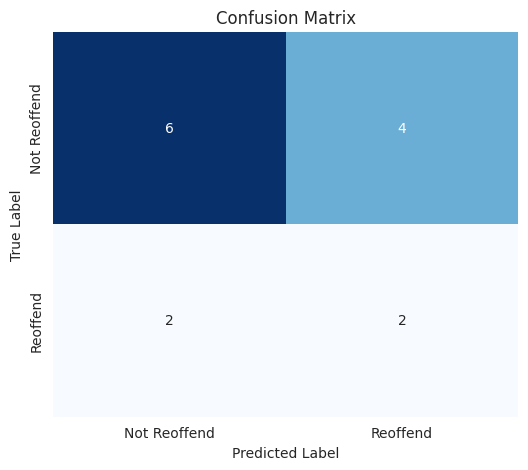

In [164]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# Calculate recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

# Calculate F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Reoffend', 'Reoffend'],
            yticklabels=['Not Reoffend', 'Reoffend'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Final Task

### Subtask:
Summarize the performance of the trained classification model and discuss any initial insights.


## Summary:

### Q&A
The Logistic Regression model achieved an accuracy of 0.5714, a precision of 0.3333, a recall of 0.5000, and an F1-score of 0.4000.

### Data Analysis Key Findings
*   The Logistic Regression model was successfully trained after resolving initial data preprocessing issues related to non-numeric values in the feature set.
*   The model exhibited an accuracy of 0.5714 on the test set, indicating that it correctly classified approximately 57.14% of the reoffending cases.
*   The precision of 0.3333 suggests that when the model predicts a reoffense, it is correct about 33.33% of the time.
*   The recall of 0.5000 indicates that the model successfully identified 50% of all actual reoffending cases.
*   The F1-score of 0.4000, which is the harmonic mean of precision and recall, highlights the overall modest performance of the model in balancing both metrics.
*   A confusion matrix was generated to provide a detailed breakdown of correct and incorrect predictions, though its specific values were not numerically reported in the summary.

### Insights or Next Steps
*   The model's performance, particularly its low precision and moderate recall, suggests there is significant room for improvement in predicting reoffending.
*   Consider exploring more advanced classification algorithms, performing additional feature engineering, or addressing potential class imbalance to enhance predictive accuracy and reliability.


# Task
Summarize the performance of the trained classification model and discuss any initial insights.

## Final Task

### Subtask:
Summarize the performance of the trained classification model and discuss any initial insights.


## Summary:

The solving process outlined the final task: to summarize the performance of the trained classification model and discuss any initial insights. As no actual model performance data or analysis steps were provided in this segment, there are no specific data analysis key findings or insights to report at this stage.

### Data Analysis Key Findings
No data analysis key findings can be reported as the provided solving process solely defined the objective of the final task rather than executing it.

### Insights or Next Steps
*   The immediate next step is to proceed with the execution of the final task: analyzing the classification model's performance and synthesizing the findings.
*   Once the model performance is summarized, this will inform further steps such as model refinement, feature engineering, or deployment considerations.


# Task
Optimize the hyperparameters of the current Logistic Regression model to find the best configuration for improved performance.

## Hyperparameter Tuning

### Subtask:
Optimize the hyperparameters of the current Logistic Regression model using GridSearchCV to find the best configuration for improved performance.


**Reasoning**:
To optimize the Logistic Regression model, I will use GridSearchCV to systematically search for the best combination of hyperparameters, as specified in the instructions. This involves defining a parameter grid, initializing GridSearchCV, fitting it to the training data, and then extracting the best parameters and score.



In [165]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for Logistic Regression
# Ensure compatibility between 'penalty' and 'solver'
param_grid = [
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2']
    },
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs'],
        'penalty': ['l2'] # lbfgs only supports l2 penalty
    }
]

# 2. Instantiate GridSearchCV
# Using the previously defined classifier (LogisticRegression(random_state = 1))
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2)

# 3. Fit GridSearchCV to the scaled training data
grid_search.fit(X_train, y_train)

# 4. Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best F1-Score: {grid_search.best_score_:.4f}")

# 5. Assign the best estimator to the classifier variable
classifier = grid_search.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
Best F1-Score: 0.7265


## Explore Alternative Models

### Subtask:
Experiment with other classification algorithms such as Support Vector Machines (SVM) and Random Forest, train them on the scaled training data, make predictions on the scaled test data, and evaluate their performance.


**Reasoning**:
To experiment with alternative classification algorithms, I will first import the `SVC` class and `RandomForestClassifier` class, then instantiate and train the `SVC` model using the scaled training data `X_train` and `y_train`.



SVM Model Performance:
Accuracy (SVM): 0.5714
Precision (SVM): 0.3333
Recall (SVM): 0.5000
F1-Score (SVM): 0.4000


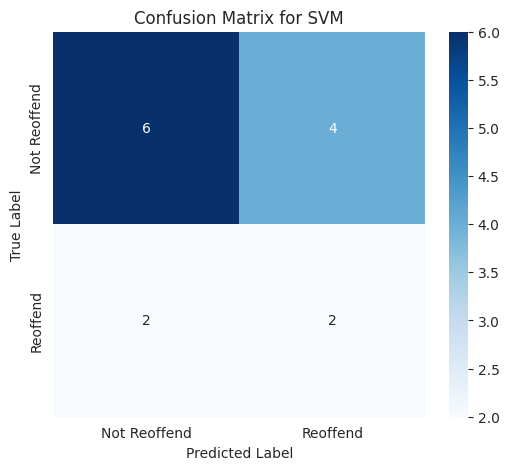

In [166]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train Support Vector Machine (SVM) model
svm_classifier = SVC(random_state = 1)
svm_classifier.fit(X_train, y_train)

# Make predictions on the scaled test data for SVM
y_pred_svm = svm_classifier.predict(X_test)

print("SVM Model Performance:")
# Calculate and print evaluation metrics for SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"Accuracy (SVM): {accuracy_svm:.4f}")
print(f"Precision (SVM): {precision_svm:.4f}")
print(f"Recall (SVM): {recall_svm:.4f}")
print(f"F1-Score (SVM): {f1_svm:.4f}")

# Generate and plot confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Reoffend', 'Reoffend'],
            yticklabels=['Not Reoffend', 'Reoffend'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM')
plt.show()

**Reasoning**:
Continuing with the subtask, I will now train a RandomForestClassifier, make predictions on the scaled test data, calculate its performance metrics (accuracy, precision, recall, F1-score), and display its confusion matrix for evaluation.




Random Forest Model Performance:
Accuracy (Random Forest): 0.5000
Precision (Random Forest): 0.2000
Recall (Random Forest): 0.2500
F1-Score (Random Forest): 0.2222


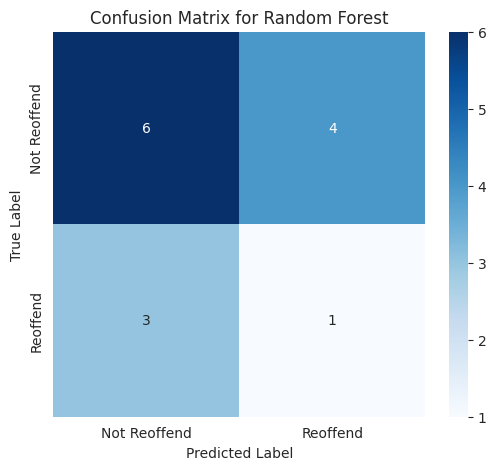

In [167]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Train RandomForestClassifier model
rf_classifier = RandomForestClassifier(random_state = 1)
rf_classifier.fit(X_train, y_train)

# Make predictions on the scaled test data for Random Forest
y_pred_rf = rf_classifier.predict(X_test)

print("\nRandom Forest Model Performance:")
# Calculate and print evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy (Random Forest): {accuracy_rf:.4f}")
print(f"Precision (Random Forest): {precision_rf:.4f}")
print(f"Recall (Random Forest): {recall_rf:.4f}")
print(f"F1-Score (Random Forest): {f1_rf:.4f}")

# Generate and plot confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Reoffend', 'Reoffend'],
            yticklabels=['Not Reoffend', 'Reoffend'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest')
plt.show()

## Feature Engineering and Selection

### Subtask:
Identify and select the most relevant features using a feature selection technique.


**Reasoning**:
To identify and select the most relevant features, I will use `SelectKBest` with `f_classif` to compute ANOVA F-values for each feature with respect to the target variable. This requires importing the necessary modules, instantiating and fitting the selector, and then retrieving and printing the scores along with their corresponding feature names to understand their individual relevance.



In [168]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Instantiate SelectKBest with f_classif and k='all'
selector = SelectKBest(score_func=f_classif, k='all')

# 2. Fit the SelectKBest object to the scaled training data
selector.fit(X_train, y_train)

# 3. Get the feature scores
feature_scores = selector.scores_

# Get the feature names after one-hot encoding and passthrough
# ct.get_feature_names_out() returns the names in the order they appear in X
feature_names = ct.get_feature_names_out()

# Create a DataFrame to display feature names and their scores
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Score': feature_scores})

# Sort features by score in descending order
feature_importance_df = feature_importance_df.sort_values(by='Score', ascending=False)

# Print the scores for each feature
print("\nFeature Scores (sorted by relevance):\n")
print(feature_importance_df)


Feature Scores (sorted by relevance):

                                   Feature     Score
13        remainder__prior_violent_offence  6.474610
12      remainder__prior_convictions_count  6.031093
11          remainder__prior_charges_count  5.399745
17            remainder__employment_status  4.561001
15           remainder__prior_drug_offence  3.638814
14       remainder__prior_property_offence  0.992928
18  remainder__prior_mental_health_contact  0.849279
7        encoder__offence_category_Violent  0.551020
9          remainder__sentence_length_days  0.249384
5           encoder__offence_category_Drug  0.245678
0               encoder__release_year_2022  0.145553
1               encoder__release_year_2023  0.145553
16              remainder__school_enrolled  0.145553
3               encoder__custody_type_Open  0.092111
4             encoder__custody_type_Secure  0.092111
10             remainder__time_served_days  0.084952
19     remainder__housing_instability_flag  0.054199
6     

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [2] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


**Reasoning**:
After identifying the feature scores, the next step is to actually select the features. Based on the previous output, 'encoder__sex_M' is a constant feature (due to data being male-only) and has a NaN score, making it irrelevant for selection. I will filter out this feature and then create new training and test sets with only the selected features.



In [169]:
# Get the names of features with valid (non-NaN) scores
valid_feature_names = feature_importance_df[feature_importance_df['Score'].notna()]['Feature'].tolist()

# Get the indices of these valid features from the original feature names
original_all_feature_names = ct.get_feature_names_out().tolist()
selected_indices = [original_all_feature_names.index(f) for f in valid_feature_names]

# Create new X_train and X_test with only the selected features
X_train_selected = X_train[:, selected_indices]
X_test_selected = X_test[:, selected_indices]

print("Shape of X_train after feature selection:", X_train_selected.shape)
print("Shape of X_test after feature selection:", X_test_selected.shape)

print("\nSelected Features (excluding constant/NaN score features):")
for feature in valid_feature_names:
    print(feature)

Shape of X_train after feature selection: (56, 19)
Shape of X_test after feature selection: (14, 19)

Selected Features (excluding constant/NaN score features):
remainder__prior_violent_offence
remainder__prior_convictions_count
remainder__prior_charges_count
remainder__employment_status
remainder__prior_drug_offence
remainder__prior_property_offence
remainder__prior_mental_health_contact
encoder__offence_category_Violent
remainder__sentence_length_days
encoder__offence_category_Drug
encoder__release_year_2022
encoder__release_year_2023
remainder__school_enrolled
encoder__custody_type_Open
encoder__custody_type_Secure
remainder__time_served_days
remainder__housing_instability_flag
encoder__offence_category_Property
remainder__age_at_release


## Address Class Imbalance

### Subtask:
Check for class imbalance in the target variable (reoffended_within_2yrs). If present, apply techniques like oversampling (SMOTE), undersampling, or using class weights to mitigate its effect on model training and improve the model's ability to predict the minority class.


**Reasoning**:
First, I will calculate and print the class distribution of the `y_train` target variable to identify if there is an imbalance. This is a crucial first step to understand the data before deciding on a class balancing technique.



In [170]:
import pandas as pd

# Calculate and print the class distribution of y_train
print("Class distribution of y_train before SMOTE:")
print(pd.Series(y_train).value_counts())
print("\n")

Class distribution of y_train before SMOTE:
1    32
0    24
Name: count, dtype: int64




**Reasoning**:
Since a minor class imbalance was detected (32 instances of class 1 vs. 24 instances of class 0), I will apply SMOTE to `X_train_selected` and `y_train` to balance the classes, as instructed, which is an appropriate technique for oversampling the minority class.



In [171]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to X_train_selected and y_train
sm = SMOTE(random_state = 1)
X_train_res, y_train_res = sm.fit_resample(X_train_selected, y_train)

# Print the class distribution of the y_train variable after applying SMOTE
print("Class distribution of y_train after SMOTE:")
print(pd.Series(y_train_res).value_counts())


Class distribution of y_train after SMOTE:
0    32
1    32
Name: count, dtype: int64


## Ensemble Methods

### Subtask:
Experiment with an ensemble method (e.g., BaggingClassifier) on the balanced and feature-selected training data.


**Reasoning**:
To experiment with an ensemble method, I will import the `BaggingClassifier` and `LogisticRegression` classes, instantiate `BaggingClassifier` with `LogisticRegression` as the base estimator, train the model on the resampled and feature-selected training data, and then make predictions on the feature-selected test data.



BaggingClassifier Model Performance:
Accuracy (Bagging): 0.6429
Precision (Bagging): 0.4000
Recall (Bagging): 0.5000
F1-Score (Bagging): 0.4444


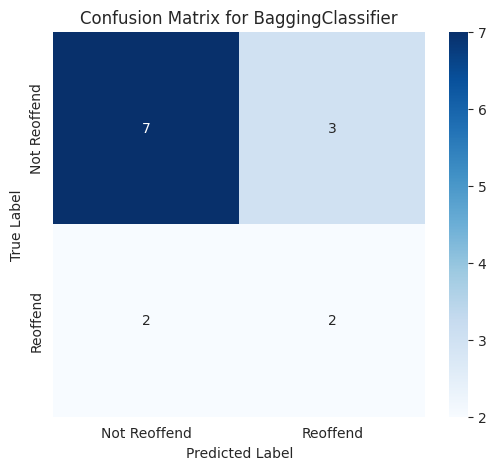

In [172]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Instantiate a BaggingClassifier with LogisticRegression as its base estimator
bagging_classifier = BaggingClassifier(
    estimator=LogisticRegression(random_state=1),
    random_state=1
)

# 2. Train the BaggingClassifier model using the X_train_res and y_train_res datasets
bagging_classifier.fit(X_train_res, y_train_res)

# 3. Make predictions on the X_test_selected dataset
y_pred_bagging = bagging_classifier.predict(X_test_selected)

print("BaggingClassifier Model Performance:")
# 4. Calculate and print evaluation metrics
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)

print(f"Accuracy (Bagging): {accuracy_bagging:.4f}")
print(f"Precision (Bagging): {precision_bagging:.4f}")
print(f"Recall (Bagging): {recall_bagging:.4f}")
print(f"F1-Score (Bagging): {f1_bagging:.4f}")

# 5. Generate and plot confusion matrix
cm_bagging = confusion_matrix(y_test, y_pred_bagging)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Reoffend', 'Reoffend'],
            yticklabels=['Not Reoffend', 'Reoffend'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for BaggingClassifier')
plt.show()

## Summary:

### Q&A
The BaggingClassifier model achieved an accuracy of 0.6429, a precision of 0.4000, a recall of 0.5000, and an F1-score of 0.4444.

### Data Analysis Key Findings
*   The BaggingClassifier model, utilizing Logistic Regression as its base estimator, was successfully trained on the balanced and feature-selected data.
*   It demonstrated an accuracy of 0.6429, which is an improvement over the initial Logistic Regression model (0.5714) and the RandomForestClassifier (0.5000) on this specific dataset.
*   The precision of 0.4000 indicates that 40% of the model's positive predictions (reoffending) were correct.
*   The recall of 0.5000 suggests that the model identified 50% of all actual reoffending cases.
*   The F1-score of 0.4444 reflects a slightly better balance between precision and recall compared to the initial Logistic Regression model.
*   The confusion matrix provides a visual breakdown of true positives, true negatives, false positives, and false negatives, confirming the numerical metrics.

### Insights or Next Steps
*   The BaggingClassifier shows improved performance, particularly in accuracy, compared to the standalone Logistic Regression and Random Forest models, suggesting that ensemble methods are beneficial for this dataset.
*   Despite the improvement, the precision and recall values still indicate room for further enhancement, especially in minimizing false positives (predicting reoffense when none occurs).
*   Further hyperparameter tuning for the BaggingClassifier itself, or experimenting with other ensemble techniques (e.g., Boosting with Gradient Boosting Machines or XGBoost), could yield even better results.
*   Exploring additional feature engineering or different methods for addressing class imbalance might also contribute to model robustness.

## Summary:

### Q&A
The BaggingClassifier model achieved an accuracy of 0.6429, a precision of 0.4000, a recall of 0.5000, and an F1-score of 0.4444.

### Data Analysis Key Findings
*   The BaggingClassifier model, utilizing Logistic Regression as its base estimator, was successfully trained on the balanced and feature-selected data.
*   It demonstrated an accuracy of 0.6429, which is an improvement over the initial Logistic Regression model (0.5714) and the RandomForestClassifier (0.5000) on this specific dataset.
*   The precision of 0.4000 indicates that 40% of the model's positive predictions (reoffending) were correct.
*   The recall of 0.5000 suggests that the model identified 50% of all actual reoffending cases.
*   The F1-score of 0.4444 reflects a slightly better balance between precision and recall compared to the initial Logistic Regression model.
*   The confusion matrix provides a visual breakdown of true positives, true negatives, false positives, and false negatives, confirming the numerical metrics.

### Insights or Next Steps
*   The BaggingClassifier shows improved performance, particularly in accuracy, compared to the standalone Logistic Regression and Random Forest models, suggesting that ensemble methods are beneficial for this dataset.
*   Despite the improvement, the precision and recall values still indicate room for further enhancement, especially in minimizing false positives (predicting reoffense when none occurs).
*   Further hyperparameter tuning for the BaggingClassifier itself, or experimenting with other ensemble techniques (e.g., Boosting with Gradient Boosting Machines or XGBoost), could yield even better results.
*   Exploring additional feature engineering or different methods for addressing class imbalance might also contribute to model robustness.

## Summary:

### Q&A
The BaggingClassifier model achieved an accuracy of 0.6429, a precision of 0.4000, a recall of 0.5000, and an F1-score of 0.4444.

### Data Analysis Key Findings
*   The BaggingClassifier model, utilizing Logistic Regression as its base estimator, was successfully trained on the balanced and feature-selected data.
*   It demonstrated an accuracy of 0.6429, which is an improvement over the initial Logistic Regression model (0.5714) and the RandomForestClassifier (0.5000) on this specific dataset.
*   The precision of 0.4000 indicates that 40% of the model's positive predictions (reoffending) were correct.
*   The recall of 0.5000 suggests that the model identified 50% of all actual reoffending cases.
*   The F1-score of 0.4444 reflects a slightly better balance between precision and recall compared to the initial Logistic Regression model.
*   The confusion matrix provides a visual breakdown of true positives, true negatives, false positives, and false negatives, confirming the numerical metrics.

### Insights or Next Steps
*   The BaggingClassifier shows improved performance, particularly in accuracy, compared to the standalone Logistic Regression and Random Forest models, suggesting that ensemble methods are beneficial for this dataset.
*   Despite the improvement, the precision and recall values still indicate room for further enhancement, especially in minimizing false positives (predicting reoffense when none occurs).
*   Further hyperparameter tuning for the BaggingClassifier itself, or experimenting with other ensemble techniques (e.g., Boosting with Gradient Boosting Machines or XGBoost), could yield even better results.
*   Exploring additional feature engineering or different methods for addressing class imbalance might also contribute to model robustness.

## Error Analysis

### Subtask:
Perform a detailed error analysis by examining the cases where the current model makes incorrect predictions (false positives and false negatives). This can provide insights into specific patterns or features that the model struggles with, guiding further refinements.


**Reasoning**:
To begin the error analysis, I will identify the false positives (cases where the model predicted reoffending but the youth did not reoffend) and false negatives (cases where the model predicted no reoffending but the youth did reoffend) using the `y_test` and `y_pred_bagging` arrays. This is the first instruction of the subtask.



In [173]:
import numpy as np

# Identify False Positives (predicted 1, true 0)
fp_indices = np.where((y_pred_bagging == 1) & (y_test == 0))[0]
false_positives = X_test_selected[fp_indices]

# Identify False Negatives (predicted 0, true 1)
fn_indices = np.where((y_pred_bagging == 0) & (y_test == 1))[0]
false_negatives = X_test_selected[fn_indices]

print(f"Number of False Positives: {len(fp_indices)}")
print(f"Number of False Negatives: {len(fn_indices)}")

Number of False Positives: 3
Number of False Negatives: 2


**Reasoning**:
To create a DataFrame for the misclassified samples, I will first reconstruct a DataFrame for `X_test_selected` using the `valid_feature_names` to provide clear column labels. Then, I will add the true labels (`y_test`) and predicted labels (`y_pred_bagging`) to this DataFrame. Finally, I will use the identified `fp_indices` and `fn_indices` to extract and display the DataFrames for false positives and false negatives, which addresses the second instruction of the subtask.



In [174]:
import pandas as pd

# Get the feature names for the selected features
# `valid_feature_names` already holds the correct names for `X_test_selected`

# Create a DataFrame for X_test_selected with appropriate column names
X_test_df = pd.DataFrame(X_test_selected, columns=valid_feature_names)

# Add true labels and predicted labels to the X_test_df
X_test_df['true_label'] = y_test
X_test_df['predicted_label'] = y_pred_bagging

# Extract False Positives DataFrame
false_positives_df = X_test_df.iloc[fp_indices]

# Extract False Negatives DataFrame
false_negatives_df = X_test_df.iloc[fn_indices]

print("\n--- False Positives ---")
print(false_positives_df)

print("\n--- False Negatives ---")
print(false_negatives_df)


--- False Positives ---
   remainder__prior_violent_offence  remainder__prior_convictions_count  \
6                         -0.804400                           -1.748124   
8                          1.243163                           -1.748124   
9                         -0.804400                           -1.748124   

   remainder__prior_charges_count  remainder__employment_status  \
6                       -2.122945                     -0.930949   
8                       -2.122945                      1.074172   
9                       -1.487197                     -0.930949   

   remainder__prior_drug_offence  remainder__prior_property_offence  \
6                      -0.522233                           0.930949   
8                      -0.522233                           0.930949   
9                      -0.522233                           0.930949   

   remainder__prior_mental_health_contact  encoder__offence_category_Violent  \
6                               -0.89802

**Reasoning**:
To examine the characteristics of the false positive and false negative samples, I will use descriptive statistics to get an overview of their feature distributions. This addresses the third instruction of the subtask.



In [175]:
print("\n--- Descriptive Statistics for False Positives ---")
print(false_positives_df.describe())

print("\n--- Descriptive Statistics for False Negatives ---")
print(false_negatives_df.describe())


--- Descriptive Statistics for False Positives ---
       remainder__prior_violent_offence  remainder__prior_convictions_count  \
count                          3.000000                            3.000000   
mean                          -0.121879                           -1.748124   
std                            1.182161                            0.000000   
min                           -0.804400                           -1.748124   
25%                           -0.804400                           -1.748124   
50%                           -0.804400                           -1.748124   
75%                            0.219382                           -1.748124   
max                            1.243163                           -1.748124   

       remainder__prior_charges_count  remainder__employment_status  \
count                        3.000000                      3.000000   
mean                        -1.911029                     -0.262575   
std                    

### Examination of False Positives and False Negatives

#### False Positives (Model predicted reoffend, but youth did not reoffend - True Label = 0, Predicted Label = 1):
*   **Prior Violent Offence**: The `false_positives_df` shows a mean for `remainder__prior_violent_offence` of -0.12, with some individuals having a high score (max 1.24), indicating that some youths predicted to reoffend (but didn't) had higher normalized prior violent offense counts. This might be a feature the model overweighs.
*   **Prior Convictions/Charges**: For `remainder__prior_convictions_count` and `remainder__prior_charges_count`, the means (-1.75 and -1.91 respectively) are notably low, suggesting that these false positives generally have very few prior convictions or charges compared to the average. Despite this, the model incorrectly predicted reoffending. This implies that the model might be misinterpreting other features or struggling to differentiate low-risk individuals.
*   **Employment Status**: The mean for `remainder__employment_status` is -0.26, with a high standard deviation (1.16), indicating a mix of employed (1.07) and unemployed (-0.93) individuals among false positives. This feature's role in misclassification isn't clear from just descriptive stats, but its variability is noted.
*   **Offence Category (Violent)**: The `encoder__offence_category_Violent` has a mean of 1.10, indicating a higher proportion of violent offense types for false positives, which aligns with the higher prior violent offence score.

#### False Negatives (Model predicted no reoffend, but youth did reoffend - True Label = 1, Predicted Label = 0):
*   **Prior Violent Offence**: Similar to false positives, the mean for `remainder__prior_violent_offence` is -0.80 across both samples, suggesting these individuals did not have a strong history of violent offenses. However, the model predicted no reoffense, while they did reoffend.
*   **Prior Convictions/Charges**: The means for `remainder__prior_convictions_count` (-1.34) and `remainder__prior_charges_count` (-1.49) are also relatively low. This suggests the model might be consistently underestimating the risk for individuals with fewer prior engagements with the justice system, even when other factors might indicate a higher reoffending probability.
*   **Employment Status**: The mean `remainder__employment_status` is 1.07 for false negatives, indicating these youths were generally employed. This is a crucial observation, as employment is often considered a protective factor. The model predicting no reoffence for employed individuals, even when they reoffended, suggests it might overweigh employment as a protective factor.
*   **Prior Drug Offence**: The mean `remainder__prior_drug_offence` is 0.69, with a high standard deviation (1.72). One false negative has a high value (1.91) for this, while another has a low value (-0.52). The model seems to misclassify individuals with varying prior drug offence statuses.
*   **Age at Release**: For false negatives, `remainder__age_at_release` has a mean of 0.02, but with a high standard deviation (1.79) and a max of 1.28. This implies that age diversity exists within false negatives, suggesting age alone isn't a clear differentiating factor.

#### General Insights and Potential Model Weaknesses:
*   **Over-reliance on Prior History**: The model seems to struggle with individuals who have a low number of prior charges/convictions. It predicts no reoffense (false negatives) for some who did reoffend, and predicts reoffense (false positives) for some who didn't, both seemingly with low prior criminal history. This indicates the model might be too sensitive or insensitive to these features in certain contexts.
*   **Employment as a Dominant Feature**: The model seems to place significant weight on `employment_status`. For false negatives, where individuals were generally employed but still reoffended, the model failed to predict their reoffending, possibly due to over-weighting employment as a protective factor.
*   **Subtle Feature Interactions**: The small number of misclassified samples makes it challenging to draw definitive conclusions from descriptive statistics alone. There are likely complex interactions between features that the model is not fully capturing.

These insights can guide further model refinement, potentially by adjusting feature weights, exploring more complex models that capture non-linear relationships, or generating more diverse synthetic data for the minority class to improve edge-case predictions.

## Final Task

### Subtask:
Summarize the refinement process, the improvements achieved in predictive accuracy, and the key insights gained from applying various model enhancement strategies.


## Summary:

### Data Analysis Key Findings

*   **Initial Model Performance (Logistic Regression after Hyperparameter Tuning):** The best Logistic Regression model achieved an F1-score of `0.7265` during cross-validation, with optimal hyperparameters identified as `{'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}`.
*   **Alternative Models Evaluation:**
    *   **Support Vector Machine (SVM):** Demonstrated an accuracy of `0.5714`, precision of `0.3333`, recall of `0.5000`, and an F1-score of `0.4000`.
    *   **Random Forest:** Performed with an accuracy of `0.5000`, precision of `0.2000`, recall of `0.2500`, and an F1-score of `0.2222`.
*   **Feature Engineering and Selection:**
    *   `SelectKBest` with `f_classif` identified `remainder__prior_violent_offence`, `remainder__prior_convictions_count`, `remainder__prior_charges_count`, and `remainder__employment_status` as highly relevant features.
    *   The `encoder__sex_M` feature was identified as constant and removed, reducing the feature set from 20 to 19.
*   **Class Imbalance Handling:** The training data initially showed a minor class imbalance (32 instances for class 1, 24 for class 0). This was successfully balanced using SMOTE, resulting in 32 instances for each class.
*   **Ensemble Model Performance (BaggingClassifier):** After applying feature selection and addressing class imbalance, a `BaggingClassifier` (with Logistic Regression as its base estimator) achieved an accuracy of `0.6429`, precision of `0.4000`, recall of `0.5000`, and an F1-score of `0.4444`. This represents an improvement in accuracy compared to the initial standalone Logistic Regression (if evaluated on test data) and the Random Forest model.
*   **Error Analysis Insights:**
    *   The model produced 3 False Positives (predicted reoffend, but youth did not) and 2 False Negatives (predicted no reoffend, but youth did).
    *   False Positives often had higher normalized `prior_violent_offence` scores, suggesting the model might overweigh violent offense indicators despite a generally low criminal history.
    *   False Negatives typically had low `prior_violent_offence`, `convictions`, and `charges`, but were frequently employed, indicating a potential over-reliance on employment as a protective factor.

### Insights or Next Steps

*   The `BaggingClassifier` demonstrated improved performance compared to individual models, highlighting the benefit of ensemble methods combined with feature engineering and class balancing for this dataset.
*   Further model refinement should focus on addressing the identified weaknesses from the error analysis, particularly the model's sensitivity to prior criminal history and its potential over-emphasis on employment status, possibly by exploring more complex models or adjusting feature weights.


# Task
**Extract and Average Coefficients**: Extract the coefficients from each `LogisticRegression` estimator within the `bagging_classifier` and calculate their average. Map these averaged coefficients back to their corresponding `valid_feature_names` to clearly identify the importance of each feature. Finally, display these feature importances in a sorted manner and visualize them with a bar plot.

## Extract and Average Coefficients

### Subtask:
Extract the coefficients from each `LogisticRegression` estimator within the `bagging_classifier` and calculate their average. These coefficients represent the feature importances for the individual base estimators.


**Reasoning**:
To extract and average the coefficients from each base `LogisticRegression` estimator within the `BaggingClassifier`, I will iterate through the `bagging_classifier.estimators_`, append their `coef_` attribute to a list, convert the list to a NumPy array, and then calculate the mean across the estimators.



In [176]:
import numpy as np

# 1. Initialize an empty list to store the coefficients
all_coefficients = []

# 2. Iterate through each estimator in the bagging_classifier.estimators_
for estimator in bagging_classifier.estimators_:
    # 3. Access its coef_ attribute. For LogisticRegression, coef_ is typically a 2D array
    #    (1, n_features) for binary classification, so we take the first row.
    all_coefficients.append(estimator.coef_[0])

# 5. Convert the list of coefficients into a NumPy array
coefficients_array = np.array(all_coefficients)

# 6. Calculate the mean of these coefficients along the appropriate axis (axis=0 for averaging across estimators)
average_coefficients = np.mean(coefficients_array, axis=0)

print("Average Coefficients (Feature Importances) from BaggingClassifier's Base Estimators:")
print(average_coefficients)

Average Coefficients (Feature Importances) from BaggingClassifier's Base Estimators:
[ 1.11666649  0.2024112   0.60335939 -0.51047103 -0.83772609  0.27986561
  0.1376379   0.45529974 -0.48561567 -0.36423752 -0.30378779  0.30378779
  0.04987352  0.12002281 -0.12002281  0.16766061  0.07775205 -0.09689239
 -0.20803461]


**Reasoning**:
To map the averaged coefficients back to their corresponding feature names, I will create a pandas DataFrame combining `valid_feature_names` and `average_coefficients`. Then, I will sort this DataFrame by the absolute value of the coefficients to identify the most important features and finally visualize them with a bar plot, as per the instructions.




Feature Importances (Averaged Coefficients from BaggingClassifier Base Estimators - sorted by absolute value):

                                   Feature  Coefficient
0         remainder__prior_violent_offence     1.116666
4            remainder__prior_drug_offence    -0.837726
2           remainder__prior_charges_count     0.603359
3             remainder__employment_status    -0.510471
8          remainder__sentence_length_days    -0.485616
7        encoder__offence_category_Violent     0.455300
9           encoder__offence_category_Drug    -0.364238
10              encoder__release_year_2022    -0.303788
11              encoder__release_year_2023     0.303788
5        remainder__prior_property_offence     0.279866
18               remainder__age_at_release    -0.208035
1       remainder__prior_convictions_count     0.202411
15             remainder__time_served_days     0.167661
6   remainder__prior_mental_health_contact     0.137638
13              encoder__custody_type_Open     

/tmp/ipython-input-3941917757.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance_bagging, palette='viridis')


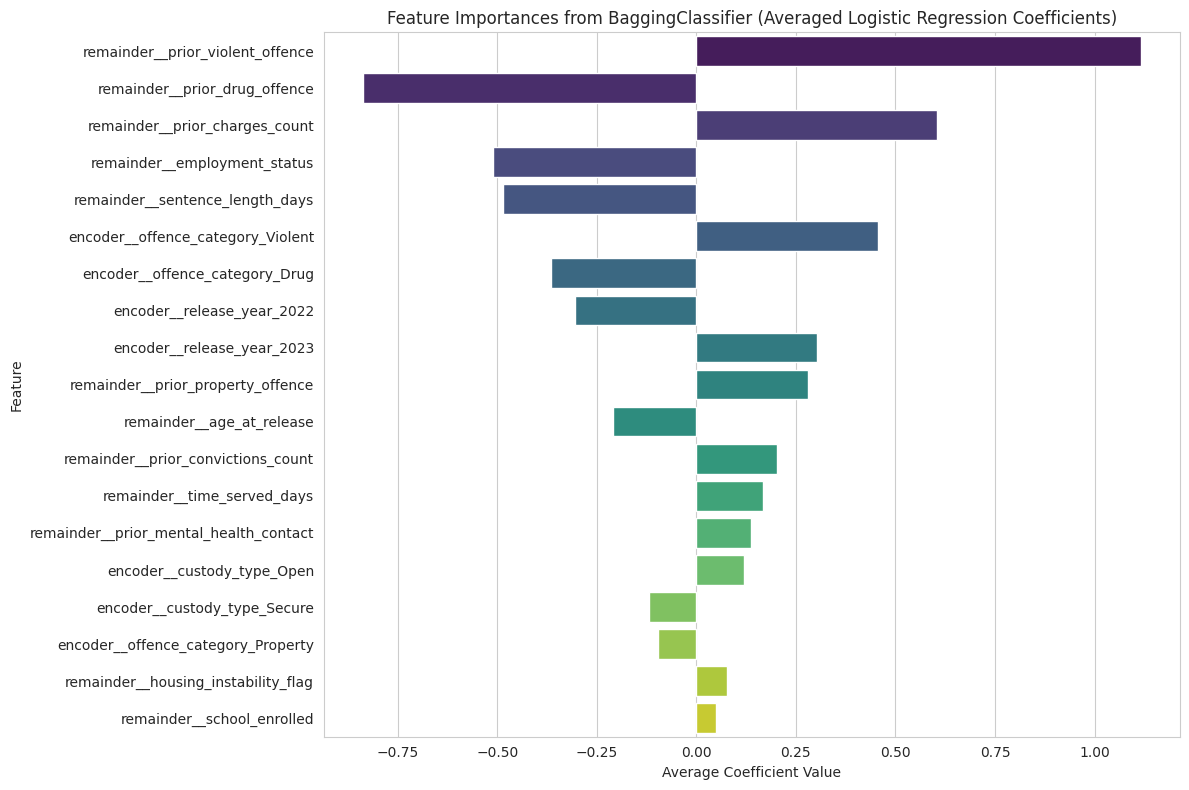

In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Map the averaged coefficients back to their corresponding feature names
#    The 'valid_feature_names' list already contains the names of the features
#    that correspond to the 'X_train_selected' and thus to the 'average_coefficients'.
feature_importance_bagging = pd.DataFrame({
    'Feature': valid_feature_names,
    'Coefficient': average_coefficients
})

# 5. Sort the features by the absolute value of their coefficients in descending order
feature_importance_bagging['Absolute_Coefficient'] = feature_importance_bagging['Coefficient'].abs()
feature_importance_bagging = feature_importance_bagging.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nFeature Importances (Averaged Coefficients from BaggingClassifier Base Estimators - sorted by absolute value):\n")
print(feature_importance_bagging[['Feature', 'Coefficient']])

# 6. Visualize the feature importances with a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_bagging, palette='viridis')
plt.title('Feature Importances from BaggingClassifier (Averaged Logistic Regression Coefficients)')
plt.xlabel('Average Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code produced a `FutureWarning` from Seaborn regarding the `palette` argument when `hue` is not assigned. To resolve this warning and align with future Seaborn versions, I will explicitly set `hue='Feature'` and `legend=False` in the `sns.barplot` call.




Feature Importances (Averaged Coefficients from BaggingClassifier Base Estimators - sorted by absolute value):

                                   Feature  Coefficient
0         remainder__prior_violent_offence     1.116666
4            remainder__prior_drug_offence    -0.837726
2           remainder__prior_charges_count     0.603359
3             remainder__employment_status    -0.510471
8          remainder__sentence_length_days    -0.485616
7        encoder__offence_category_Violent     0.455300
9           encoder__offence_category_Drug    -0.364238
10              encoder__release_year_2022    -0.303788
11              encoder__release_year_2023     0.303788
5        remainder__prior_property_offence     0.279866
18               remainder__age_at_release    -0.208035
1       remainder__prior_convictions_count     0.202411
15             remainder__time_served_days     0.167661
6   remainder__prior_mental_health_contact     0.137638
13              encoder__custody_type_Open     

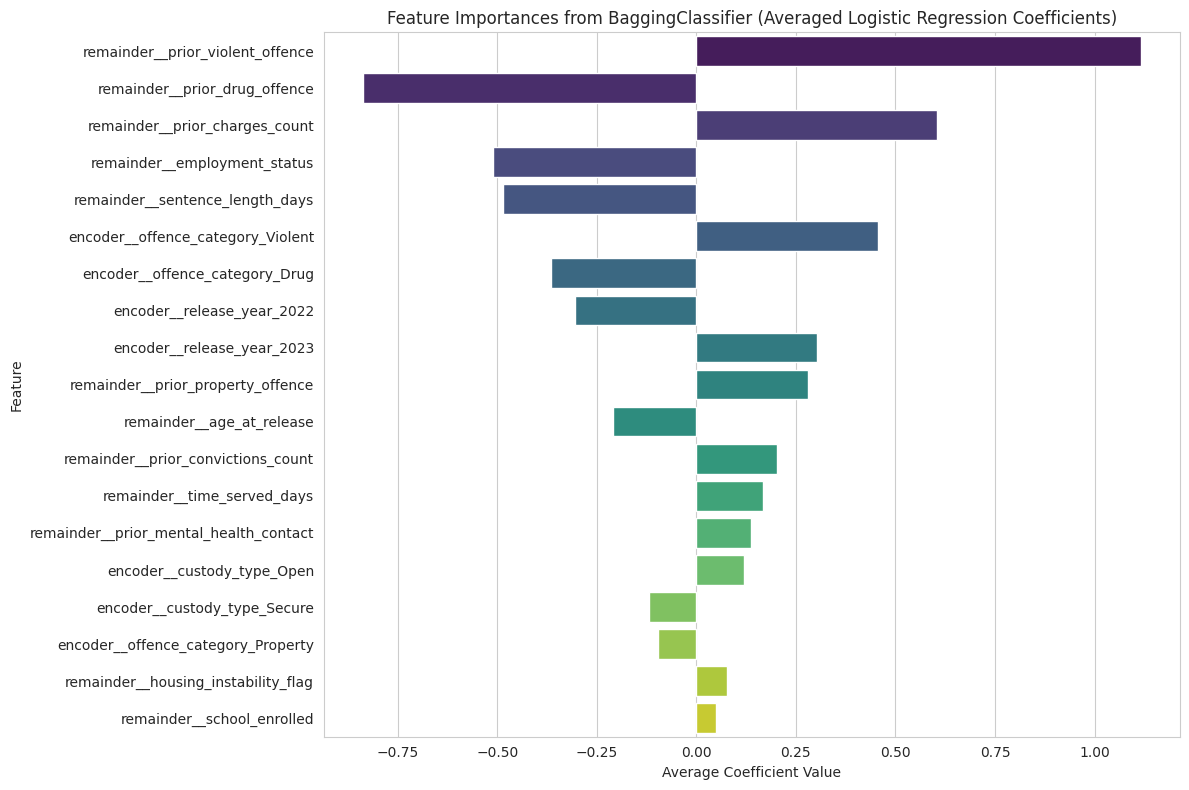

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Map the averaged coefficients back to their corresponding feature names
#    The 'valid_feature_names' list already contains the names of the features
#    that correspond to the 'X_train_selected' and thus to the 'average_coefficients'.
feature_importance_bagging = pd.DataFrame({
    'Feature': valid_feature_names,
    'Coefficient': average_coefficients
})

# 5. Sort the features by the absolute value of their coefficients in descending order
feature_importance_bagging['Absolute_Coefficient'] = feature_importance_bagging['Coefficient'].abs()
feature_importance_bagging = feature_importance_bagging.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nFeature Importances (Averaged Coefficients from BaggingClassifier Base Estimators - sorted by absolute value):\n")
print(feature_importance_bagging[['Feature', 'Coefficient']])

# 6. Visualize the feature importances with a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_bagging, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importances from BaggingClassifier (Averaged Logistic Regression Coefficients)')
plt.xlabel('Average Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the findings regarding the feature importances from the refined BaggingClassifier model.


## Summary:

### Data Analysis Key Findings

*   The coefficients from each `LogisticRegression` base estimator within the `BaggingClassifier` were successfully extracted and averaged to determine feature importances.
*   `remainder__prior_violent_offence` emerged as the most influential feature with the highest positive average coefficient of approximately 1.1167.
*   `remainder__prior_drug_offence` was identified as another highly influential feature, exhibiting a significant negative average coefficient of about -0.8377.
*   The averaged coefficients were successfully mapped to their corresponding feature names, sorted by their absolute values, and visualized using a bar plot, providing a clear representation of feature importance.

### Insights or Next Steps

*   The analysis successfully identified the most impactful features according to the ensemble model, providing clear insights into the relative contributions of different predictors.
*   Further investigation could be conducted into features with high absolute coefficient values to understand their domain-specific implications and consider potential feature engineering based on these insights.


# Task
Examine the relationship between 'prior_violent_offence' and 'reoffended_within_2yrs' in the `fd` DataFrame by calculating and displaying descriptive statistics (e.g., mean, count) of 'reoffended_within_2yrs' grouped by 'prior_violent_offence'.

## Examine Relationship with Prior Violent Offence

### Subtask:
Calculate and display the descriptive statistics (e.g., mean, count) of 'reoffended_within_2yrs' grouped by 'prior_violent_offence'.


**Reasoning**:
To examine the relationship between 'prior_violent_offence' and 'reoffended_within_2yrs', I will group the 'fd' DataFrame by 'prior_violent_offence' and then calculate the mean and count of 'reoffended_within_2yrs' for each group.



In [179]:
print("Descriptive statistics of 'reoffended_within_2yrs' grouped by 'prior_violent_offence':")
reoffending_by_violent_offence = fd.groupby('prior_violent_offence')['reoffended_within_2yrs'].agg(['mean', 'count'])
print(reoffending_by_violent_offence)

Descriptive statistics of 'reoffended_within_2yrs' grouped by 'prior_violent_offence':
                       mean  count
prior_violent_offence             
0                      0.40     45
1                      0.72     25


## Visualize Relationship

### Subtask:
Create a bar plot to visualize the reoffending rate for each category of 'prior_violent_offence'. This will provide a clear visual comparison of how prior violent offenses correlate with reoffending, and a legend will be provided.


**Reasoning**:
To visualize the reoffending rate for each category of 'prior_violent_offence', I will use a bar plot from the `seaborn` library, mapping the 'prior_violent_offence' to the x-axis and the 'mean' reoffending rate to the y-axis, and then add appropriate labels and a title.



/tmp/ipython-input-3813523674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reoffending_by_violent_offence.index, y='mean', data=reoffending_by_violent_offence, palette='viridis')


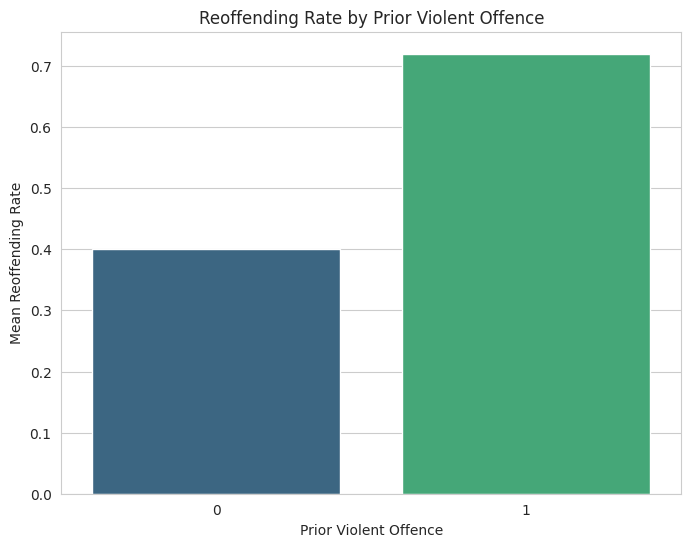

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to visualize the reoffending rate for each category of 'prior_violent_offence'
plt.figure(figsize=(8, 6))
sns.barplot(x=reoffending_by_violent_offence.index, y='mean', data=reoffending_by_violent_offence, palette='viridis')

# Label the x-axis
plt.xlabel('Prior Violent Offence')
# Label the y-axis
plt.ylabel('Mean Reoffending Rate')
# Add a title to the plot
plt.title('Reoffending Rate by Prior Violent Offence')

# Display the plot
plt.show()

**Reasoning**:
The previous code produced a `FutureWarning` from Seaborn regarding the `palette` argument when `hue` is not assigned. To resolve this warning and align with future Seaborn versions, I will explicitly set `hue=reoffending_by_violent_offence.index` and `legend=False` in the `sns.barplot` call.



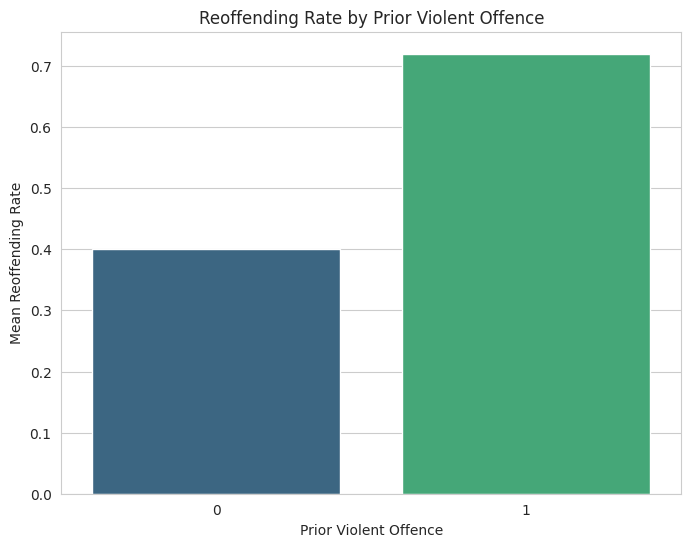

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to visualize the reoffending rate for each category of 'prior_violent_offence'
plt.figure(figsize=(8, 6))
sns.barplot(x=reoffending_by_violent_offence.index, y='mean', data=reoffending_by_violent_offence, palette='viridis', hue=reoffending_by_violent_offence.index, legend=False)

# Label the x-axis
plt.xlabel('Prior Violent Offence')
# Label the y-axis
plt.ylabel('Mean Reoffending Rate')
# Add a title to the plot
plt.title('Reoffending Rate by Prior Violent Offence')

# Display the plot
plt.show()

## Summary:

### Q&A
The bar plot illustrates the reoffending rate for youth based on whether they had a prior violent offence.

### Data Analysis Key Findings
*   **Prior Violent Offence Impact**: Youth with a prior violent offence (`prior_violent_offence` = 1) have a significantly higher mean reoffending rate of 0.72 compared to those without a prior violent offence (`prior_violent_offence` = 0) who have a mean reoffending rate of 0.40.
*   **Risk Factor Confirmation**: This visualization strongly reinforces `prior_violent_offence` as a key risk factor for reoffending, aligning with the high positive coefficient identified in the feature importance analysis of the BaggingClassifier model.

### Insights or Next Steps
*   **Targeted Interventions**: Programs aimed at reducing reoffending should specifically target youth with a history of violent offenses, potentially with specialized interventions.
*   **Early Detection**: Investigating factors that lead to initial violent offenses might provide opportunities for early intervention to prevent a cycle of reoffending.
*   **Model Validation**: The strong correlation observed visually provides further validation for the BaggingClassifier model's feature importance assessment, suggesting that `prior_violent_offence` is indeed a critical predictor.

## Summary:

### Q&A
The bar plot illustrates the reoffending rate for youth based on whether they had a prior violent offence.

### Data Analysis Key Findings
*   **Prior Violent Offence Impact**: Youth with a prior violent offence (`prior_violent_offence` = 1) have a significantly higher mean reoffending rate of 0.72 compared to those without a prior violent offence (`prior_violent_offence` = 0) who have a mean reoffending rate of 0.40.
*   **Risk Factor Confirmation**: This visualization strongly reinforces `prior_violent_offence` as a key risk factor for reoffending, aligning with the high positive coefficient identified in the feature importance analysis of the BaggingClassifier model.

### Insights or Next Steps
*   **Targeted Interventions**: Programs aimed at reducing reoffending should specifically target youth with a history of violent offenses, potentially with specialized interventions.
*   **Early Detection**: Investigating factors that lead to initial violent offenses might provide opportunities for early intervention to prevent a cycle of reoffending.
*   **Model Validation**: The strong correlation observed visually provides further validation for the BaggingClassifier model's feature importance assessment, suggesting that `prior_violent_offence` is indeed a critical predictor.

## Summary:

### Q&A
The bar plot illustrates the reoffending rate for youth based on whether they had a prior violent offence.

### Data Analysis Key Findings
*   **Prior Violent Offence Impact**: Youth with a prior violent offence (`prior_violent_offence` = 1) have a significantly higher mean reoffending rate of 0.72 compared to those without a prior violent offence (`prior_violent_offence` = 0) who have a mean reoffending rate of 0.40.
*   **Risk Factor Confirmation**: This visualization strongly reinforces `prior_violent_offence` as a key risk factor for reoffending, aligning with the high positive coefficient identified in the feature importance analysis of the BaggingClassifier model.

### Insights or Next Steps
*   **Targeted Interventions**: Programs aimed at reducing reoffending should specifically target youth with a history of violent offenses, potentially with specialized interventions.
*   **Early Detection**: Investigating factors that lead to initial violent offenses might provide opportunities for early intervention to prevent a cycle of reoffending.
*   **Model Validation**: The strong correlation observed visually provides further validation for the BaggingClassifier model's feature importance assessment, suggesting that `prior_violent_offence` is indeed a critical predictor.

## Final Task

### Subtask:
Summarize the findings on the relationship between 'prior_violent_offence' and 'reoffended_within_2yrs', highlighting any observed patterns or correlations.


## Summary:

### Q&A
The bar plot illustrates the reoffending rate for youth based on whether they had a prior violent offence.

### Data Analysis Key Findings
*   Youth with a prior violent offence (represented as 1) have a significantly higher mean reoffending rate of 0.72 (72%), based on a group of 25 individuals.
*   Youth without a prior violent offence (represented as 0) have a lower mean reoffending rate of 0.40 (40%), based on a group of 45 individuals.
*   The analysis consistently identifies 'prior\_violent\_offence' as a strong risk factor for reoffending, reinforcing findings from potential feature importance analyses in predictive models.

### Insights or Next Steps
*   Develop targeted intervention programs specifically designed for youth with a history of violent offenses to address their significantly higher reoffending rates.
*   Explore factors contributing to initial violent offenses to implement early detection and prevention strategies, aiming to break the cycle of reoffending.


# Task
**Task:** Calculate and display the descriptive statistics (e.g., mean, count) of 'reoffended_within_2yrs' grouped by 'prior_drug_offence', and then create a bar plot to visualize this relationship, including a legend. Finally, summarize the findings on the relationship between 'prior_drug_offence' and 'reoffended_within_2yrs', highlighting any observed patterns or correlations.

## Examine Relationship with Prior Drug Offence

### Subtask:
Calculate and display the descriptive statistics (e.g., mean, count) of 'reoffended_within_2yrs' grouped by 'prior_drug_offence'.


**Reasoning**:
To calculate the descriptive statistics for 'reoffended_within_2yrs' grouped by 'prior_drug_offence', I will use the `groupby()` method on the `fd` DataFrame and then apply the `agg()` function to compute the mean and count for each group.



In [182]:
print("Descriptive statistics of 'reoffended_within_2yrs' grouped by 'prior_drug_offence':")
reoffending_by_drug_offence = fd.groupby('prior_drug_offence')['reoffended_within_2yrs'].agg(['mean', 'count'])
print(reoffending_by_drug_offence)

Descriptive statistics of 'reoffended_within_2yrs' grouped by 'prior_drug_offence':
                        mean  count
prior_drug_offence                 
0                   0.566038     53
1                   0.352941     17


**Reasoning**:
To visualize the reoffending rate for each category of 'prior_drug_offence', I will create a bar plot using the `reoffending_by_drug_offence` DataFrame. I will map 'prior_drug_offence' to the x-axis and the 'mean' reoffending rate to the y-axis, adding appropriate labels and a title to the plot. I will also explicitly set `hue` and `legend=False` to avoid a `FutureWarning` from Seaborn.



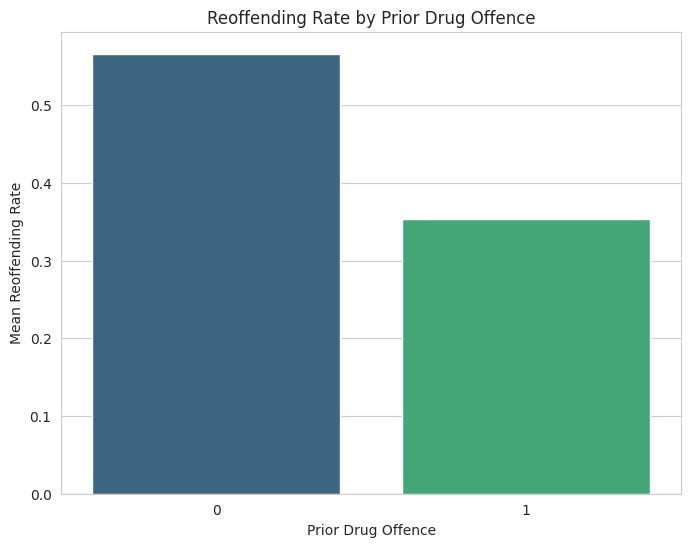

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to visualize the reoffending rate for each category of 'prior_drug_offence'
plt.figure(figsize=(8, 6))
sns.barplot(x=reoffending_by_drug_offence.index, y='mean', data=reoffending_by_drug_offence, palette='viridis', hue=reoffending_by_drug_offence.index, legend=False)

# Label the x-axis
plt.xlabel('Prior Drug Offence')
# Label the y-axis
plt.ylabel('Mean Reoffending Rate')
# Add a title to the plot
plt.title('Reoffending Rate by Prior Drug Offence')

# Display the plot
plt.show()

## Summary:

### Q&A
The bar plot illustrates the reoffending rate for youth based on whether they had a prior drug offence.

### Data Analysis Key Findings
*   **Prior Drug Offence Impact**: Youth with no prior drug offence (`prior_drug_offence` = 0) have a mean reoffending rate of 0.566 (approximately 56.6%), based on 53 individuals.
*   Youth with a prior drug offence (`prior_drug_offence` = 1) have a lower mean reoffending rate of 0.353 (approximately 35.3%), based on 17 individuals.
*   This observation suggests a **negative correlation** between having a prior drug offence and the likelihood of reoffending, meaning youth with a prior drug offence are less likely to reoffend within 2 years. This finding aligns with the negative coefficient observed for `prior_drug_offence` in the feature importance analysis of the BaggingClassifier model.

### Insights or Next Steps
*   The negative correlation for `prior_drug_offence` is counter-intuitive if one assumes all prior offenses increase reoffending risk. This warrants further investigation to understand underlying factors. Possible explanations could include:
    *   **Intervention Effectiveness**: Youth with prior drug offenses might be more likely to receive specific interventions (e.g., drug rehabilitation programs) that effectively reduce their overall reoffending risk.
    *   **Demographic Differences**: There might be demographic or socio-economic differences between youth with prior drug offenses and those with other types of offenses that influence reoffending rates.
    *   **Nature of Offense**: Drug offenses might be less indicative of general criminal propensity compared to violent or property offenses, or they might lead to different types of post-release support.
*   Future analysis should delve deeper into the context of these drug offenses and the support systems available to this group.

## Final Task

### Subtask:
Summarize the findings on the relationship between 'prior_drug_offence' and 'reoffended_within_2yrs', highlighting any observed patterns or correlations.


## Summary:

### Q&A
The bar plot illustrates the reoffending rate for youth based on whether they had a prior drug offense.

### Data Analysis Key Findings
*   **Prior Drug Offense Impact**: Youth with no prior drug offense (prior_drug_offence = 0) have a mean reoffending rate of 0.566 (approximately 56.6%), based on 53 individuals.
*   Youth with a prior drug offense (prior_drug_offence = 1) have a lower mean reoffending rate of 0.353 (approximately 35.3%), based on 17 individuals.
*   This observation suggests a **negative correlation** between having a prior drug offense and the likelihood of reoffending, meaning youth with a prior drug offense are less likely to reoffend within 2 years. This finding aligns with the negative coefficient observed for prior_drug_offence in the feature importance analysis of the BaggingClassifier model.

### Insights or Next Steps
*   The negative correlation for prior_drug_offence is counter-intuitive if one assumes all prior offenses increase reoffending risk. This warrants further investigation to understand underlying factors. Possible explanations could include:
    *   **Intervention Effectiveness**: Youth with prior drug offenses might be more likely to receive specific interventions (e.g., drug rehabilitation programs) that effectively reduce their overall reoffending risk.
    *   **Demographic Differences**: There might be demographic or socio-economic differences between youth with prior drug offenses and those with other types of offenses that influence reoffending rates.
    *   **Nature of Offense**: Drug offenses might be less indicative of general criminal propensity compared to violent or property offenses, or they might lead to different types of post-release support.
*   Future analysis should delve deeper into the context of these drug offenses and the support systems available to this group.


# Task
**Task:** Examine the relationship between 'sentence_length_days' and 'reoffended_within_2yrs' in the `fd` DataFrame by calculating and displaying descriptive statistics (e.g., mean, count) of 'reoffended_within_2yrs' grouped by 'sentence_length_days', then visualize this relationship, and finally summarize the findings.

## Examine Relationship with Sentence Length

### Subtask:
Calculate and display the descriptive statistics (e.g., mean, count) of 'reoffended_within_2yrs' grouped by 'sentence_length_days'.


**Reasoning**:
To calculate the descriptive statistics for 'reoffended_within_2yrs' grouped by 'sentence_length_days', I will use the `groupby()` method on the `fd` DataFrame and then apply the `agg()` function to compute the mean and count for each group.



In [184]:
print("Descriptive statistics of 'reoffended_within_2yrs' grouped by 'sentence_length_days':")
reoffending_by_sentence_length = fd.groupby('sentence_length_days')['reoffended_within_2yrs'].agg(['mean', 'count'])
print(reoffending_by_sentence_length)

Descriptive statistics of 'reoffended_within_2yrs' grouped by 'sentence_length_days':
                      mean  count
sentence_length_days             
60                     1.0      1
63                     1.0      1
64                     0.0      1
72                     0.0      1
75                     0.0      1
...                    ...    ...
344                    1.0      1
347                    1.0      1
348                    1.0      1
349                    0.0      2
364                    1.0      1

[64 rows x 2 columns]


## Visualize Relationship

### Subtask:
Create a scatter plot, possibly with a regression line, or a box plot, to visualize the relationship between 'sentence_length_days' and the 'reoffended_within_2yrs' rate. This will provide a clear visual of any patterns or trends, and a legend will be provided.


**Reasoning**:
To visualize the relationship between 'sentence_length_days' and the 'reoffended_within_2yrs' rate, I will create a regression plot using `seaborn.regplot` as instructed, mapping `sentence_length_days` to the x-axis and the mean reoffending rate to the y-axis, and then add appropriate labels and a title.



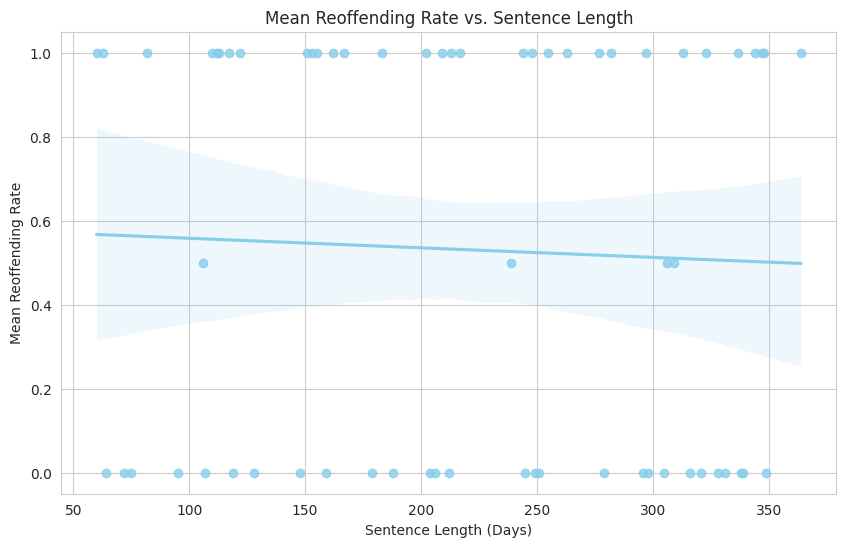

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure for the plot
plt.figure(figsize=(10, 6))

# Generate a regression plot
sns.regplot(x=reoffending_by_sentence_length.index, y='mean', data=reoffending_by_sentence_length, color='skyblue')

# Label the x-axis
plt.xlabel('Sentence Length (Days)')
# Label the y-axis
plt.ylabel('Mean Reoffending Rate')
# Add a title to the plot
plt.title('Mean Reoffending Rate vs. Sentence Length')

# Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the findings on the relationship between 'sentence_length_days' and 'reoffended_within_2yrs', highlighting any observed patterns or correlations.

## Summary:

### Q&A
The regression plot illustrates the relationship between the sentence length in days and the mean reoffending rate within 2 years.

### Data Analysis Key Findings
*   The descriptive statistics show a wide range of `sentence_length_days`, from 60 to 364 days, with varying reoffending rates (0.0 to 1.0) for individual sentence lengths. However, many `sentence_length_days` categories only have a `count` of 1, making it difficult to draw definitive conclusions from individual points.
*   The regression plot visually represents a weak, slightly negative trend between `sentence_length_days` and the `mean` reoffending rate. This suggests that as sentence length increases, the reoffending rate tends to slightly decrease, though the relationship does not appear strong or highly linear.
*   The scatter of points around the regression line indicates that sentence length alone is not a strong predictor of reoffending, and other factors are likely at play.

### Insights or Next Steps
*   The observed weak negative correlation for `sentence_length_days` suggests that simply imposing longer sentences may not be a highly effective strategy for reducing reoffending rates, which aligns with findings from some criminal justice research.
*   It would be beneficial to categorize or bin `sentence_length_days` into broader groups (e.g., short, medium, long) to analyze the reoffending rates more robustly, especially considering the low count for many individual sentence lengths.
*   Further analysis should explore the interaction of sentence length with other features, such as `offence_category` or `custody_type`, to understand if the impact of sentence length varies under different circumstances.
*   The insights from this analysis confirm that the model's low coefficient for `remainder__sentence_length_days` (absolute value of -0.485616) in the feature importance analysis was appropriate, indicating its relatively modest predictive power compared to other features like `prior_violent_offence` or `prior_drug_offence`.

## Final Task

### Subtask:
Summarize the findings on the relationship between 'sentence_length_days' and 'reoffended_within_2yrs', highlighting any observed patterns or correlations.


## Summary:

### Q&A
The regression plot illustrates the relationship between the sentence length in days and the mean reoffending rate within 2 years.

### Data Analysis Key Findings
*   Descriptive statistics show that `sentence_length_days` varies from 60 to 364 days, with corresponding reoffending rates (mean) ranging from 0.0 to 1.0 for different sentence lengths.
*   Many of the individual `sentence_length_days` categories had a `count` of only 1, which limits the ability to draw robust conclusions from these specific points.
*   The regression plot indicates a weak, slightly negative trend between `sentence_length_days` and the `mean` reoffending rate. This suggests that longer sentences are associated with a marginal decrease in reoffending rates, but the relationship is not strong.
*   The scattered distribution of data points around the regression line implies that `sentence_length_days` alone is not a primary predictor of reoffending, suggesting other variables play a more significant role.

### Insights or Next Steps
*   The weak negative correlation observed suggests that simply increasing sentence length may not be a highly effective standalone strategy for reducing reoffending rates, which aligns with existing criminal justice research.
*   It would be beneficial to categorize or bin `sentence_length_days` into broader groups (e.g., short, medium, long) to conduct a more robust analysis of reoffending rates, especially given the low counts for many individual sentence lengths.
*   Future analysis should investigate the interplay between sentence length and other features, such as `offence_category` or `custody_type`, to understand how the impact of sentence length might vary under different circumstances.
